# **Задание к хакатону по дисциплине "Агрегация, очистка и парсинг данных"**

# **Анализ HR-датасета**.

# Цель задания

Освоить полный цикл предобработки и анализа данных на примере HR-датасета.

# Исходные данные

HR-аналитики компании Банка помогают бизнесу оптимизировать управление персоналом. Для этого используется data driven подход, позволяющий принимать более точные и обоснованные решения.

Компания предоставила информацию о сотрудниках за последний год. Датасет employee_data_final.csv содержит данные о производительности, удовлетворённости работой, зарплате и других HR-метриках.

Столбец job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании. Он принимает значения **только от 0 до 1, где 0 — полностью не удовлетворен, 1 — полностью удовлетворен**.

Удовлетворённость работой напрямую влияет на отток сотрудников, поэтому её анализ и прогнозирование крайне важны для бизнеса.

# Описание датасета

•	id — уникальный идентификатор сотрудника

•	dept — отдел, в котором работает сотрудник

•	level — уровень занимаемой должности

•	workload — уровень загруженности сотрудника

•	employment_years — длительность работы в компании (в годах)

•	last_year_promo — было ли повышение за последний год

•	last_year_violations — были ли нарушения трудового договора за последний год

•	supervisor_evaluation — оценка качества работы от руководителя

•	salary — ежемесячная заработная плата

•	quit — уволился ли сотрудник

•	job_satisfaction_rate — уровень удовлетворённости работой (целевой признак)

# **Часть 1. Загрузка и первоначальное изучение данных**

1. Загрузите датасет, определите его размер, типы данных, наличие дубликатов и пропусков. При необходимости привести типы данных к корректному виду.

2. Удалите дубликаты, пропуски и** остальные аномалии**, которые покажутся вам странными. Например, вам могут встретиться неявные дубликаты или это могут быть какие-то числовые выбросы, например невероятно высокие заработные платы, будьте внимательны.

**Анализ признаков**

1. Постройте визуализации для каждого признака. Для количественных и категориальных признаков использовать соответствующие типы графиков.

2. Для каждого уровня должности (junior, middle, senior):

1.	Вычислить медианный трудовой стаж (employment_years)

2.	Рассчитать среднюю заработную плату – общую и по отделам

3.	Найти отдел с наибольшим процентом уволившихся сотрудников


# **Решение задания в части 1 (индивидуальное)**

**В данной раобте мы решаем две параллельные задачи:**

**1. Готовим данные для моделирования.** Это значит, что в результате мы должны получить датасет без пропусков, аномалий, дубликатов, с числовыми данными (т.е. корректно зашифрованными категориальными признаками без порядка (номинальные) и с порядком (ординальные). Это сквозная задача, мы будем двигаться к ее решению на протяжении всего ноутбука.

**2. Выпольнить блок аналитических вычислений и визуализаций.** Эту работу можно выполнять как на первоначальных данных (посмотреть "что есть") и обработанных (посмотреть "что стало"), а также на разных вариантах обрабтки. В связи с этим метрики мы посчитаем дважды - до заполнения пропусков и перешифровки аномалий (просто исключив их из релевантного диапазона значений), а также после всех преобразований и дозаполнений. И, сравнив, результаты. Сделаем выводы - насколько результаты с исключенными значениями отличаются от результатов после перешифровок.

**1. Импортируем библиотеки, которые могут нам понадобиться**

In [ ]:
# Импорт пакетов
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (24,16)
v = None

**2. Загрузим датасет, определим его размер (количество строк и столбцрв), посмотрим на типы данных по столбцам и выведем на просмотр его первые 5 строк (для первоначального представления о данных).**

In [ ]:
# Чтение данных
df = pd.read_csv("employee_data.csv")
# Смотрим размер датасета, типы данных по столбцам и первые 5 строк с данными
print('Размер датасета (количество строк, столбцов):', df.shape)
print('Типы данных по столбцам:\n', df.dtypes)
df.head()

Размер датасета (количество строк, столбцов): (4792513, 11)
Типы данных по столбцам:
 id                              int64
dept                           object
level                          object
workload                       object
employment_years              float64
last_year_promo                object
last_year_violations           object
supervisor_evaluation         float64
salary                        float64
quit                           object
job_satisfaction_rate_pred    float64
dtype: object


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate_pred
0,690679,finance,junior,medium,1.0,no,no,4.0,175000.0,yes,1.156844
1,125148,hr,senior,low,3.0,no,no,2.0,280000.0,no,0.745757
2,311009,sales,junior,high,2.0,no,no,1.0,105000.0,no,0.581074
3,908488,finance,junior,medium,1.0,no,no,2.0,100000.0,no,0.671288
4,756857,tech,junior,medium,1.0,no,no,2.0,100000.0,yes,0.347873


Наш датасет состоит из 4 792 513 строк и 11 столбцов.

Единственный столбец с типом данных int (целое число) - id (уникальный идентификатор сотрудника).

Тип данных float (действительное число) имеют 4 столбца:

• employment_years — длительность работы в компании (в годах);

• supervisor_evaluation — оценка качества работы от руководителя;

• salary — ежемесячная заработная плата;

• job_satisfaction_rate — уровень удовлетворённости работой (целевой признак).

Остальные признаки имеют тип object, т.е. могут содержать как числовые, так и текстовые данные.



Сразу посмотрим, какое содержимое имеют столбцы с типом данных object, так как там может быть "мусор" в заполнении, который лучше сразу почистить.

In [ ]:
# 1) Список столбцов типа object
obj_cols = df.select_dtypes(include=['object']).columns
print("Object-столбцы:", list(obj_cols))

# 2) Для каждого object-столбца: какие значения встречаются и сколько раз
for col in obj_cols:
    print("\n" + "="*80)
    print(f"{col} (unique={df[col].nunique(dropna=True)}, missing={df[col].isna().sum()})")

    vc = df[col].astype("string").value_counts(dropna=False)  # включает NaN
    # красиво подписываем пропуски
    vc.index = vc.index.fillna("<NaN>")

    print(vc.to_string())


Object-столбцы: ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'quit']

dept (unique=28, missing=30499)
dept
sales                   1192633
technology               953739
finance                  858758
hr                       715196
it                       476975
marketing                324355
<NaN>                     30499
sale                      15719
salles                    15665
saales                    15573
saless                    15565
financce                  15168
finnance                  14844
fin_department            14793
teknology                 12670
techology                 12607
tech                      12517
technolog                 12374
human_resources            9523
hrhr                       9423
hrr                        9418
hhr                        9252
itt                        8620
it_department              8386
iit                        8304
marketting                 7591
mkt                        7460
m

Видим, что кроме столбца dept, остальные 5 признаков имеют понятный набор значений, которые можно преобразовать в бинарные или ординальные признаки (категориальные со шкалами)

Столбец dept имеет различное написание отделов с одинаковым смысловым значением - их нужно привести к одной классификации, а затем к ним можно применить one-hot-encoding для последующего учета при моделировании

Приведем сразу в порядок столбец dept. Мы видим корректное написание отделов: sales, technology, finance, hr, it, marketing и разные вариации этих названий(пропуски пока не берем во внимание).

Так как корректные наименования отделов начинаются на уникальные буквы, можем перешифровать остальные названия по совпадению первых букв.

In [ ]:
# маппинг по первой букве
dept_map = {
    "s": "sales",
    "t": "technology",
    "f": "finance",
    "h": "hr",
    "i": "it",
    "m": "marketing",
}

# приводим к строке + чистим пробелы/регистр, но пропуски (NaN) оставляем как есть
s = df["dept"]
s_clean = s.astype("string").str.strip().str.lower()

df["dept"] = np.where(
    s_clean.isna(),                          # если пропуск - оставить NaN
    s,                                       # (оставляем как было, т.е. NaN)
    s_clean.str[0].map(dept_map).fillna(s_clean)  # иначе заменяем по первой букве
)


Проверяем содержимое столбца dept после перешифровки:

In [ ]:
col = "dept"

print("Столбец:", col)
print("Тип данных:", df[col].dtype)
print("Пропусков:", df[col].isna().sum())
print("Уникальных (без NaN):", df[col].nunique(dropna=True))

# Значения и их количество (включая NaN)
vc = df[col].value_counts(dropna=False)
vc.index = vc.index.to_series().apply(lambda x: "<NaN>" if pd.isna(x) else x)

print("\nЧастоты значений:")
print(vc.to_string())

Столбец: dept
Тип данных: object
Пропусков: 30499
Уникальных (без NaN): 6

Частоты значений:
dept
sales         1255155
technology    1003907
finance        903563
hr             752812
it             502285
marketing      344292
<NaN>           30499


Видим, что количество пропусков не изменилось, а названия отделов упорядочились по 6 категориям, как мы и хотели. Теперь это качественный признак, к которому для использования в модели можно применить one-hot-encoding (сделаем позже)

Из количественных признаков с типом float посмотрим на признак supervisor_evaluation

In [ ]:
col = "supervisor_evaluation"

print("Столбец:", col)
print("Тип данных:", df[col].dtype)
print("Пропусков:", df[col].isna().sum())
print("Уникальных (без NaN):", df[col].nunique(dropna=True))

# Значения и их количество (включая NaN)
vc = df[col].value_counts(dropna=False)
vc.index = vc.index.to_series().apply(lambda x: "<NaN>" if pd.isna(x) else x)

print("\nЧастоты значений:")
print(vc.to_string())


Столбец: supervisor_evaluation
Тип данных: float64
Пропусков: 29057
Уникальных (без NaN): 5

Частоты значений:
supervisor_evaluation
4.0      1949171
5.0      1368664
3.0       717332
2.0       387037
1.0       341252
<NaN>      29057


Этот признак имеет корректные значения для ординального (категориального со шкалой) признака, единственное с чем надо поработать - пропуски, мы вернемся к этому позже.

Остальные количественные признаки могут принимать множество значений в разумном диапазоне. Мы проанализируем их на наличие выбросов и аномальных значений в следующих разделах нашего анализа.

**3. Работа с пропусками**

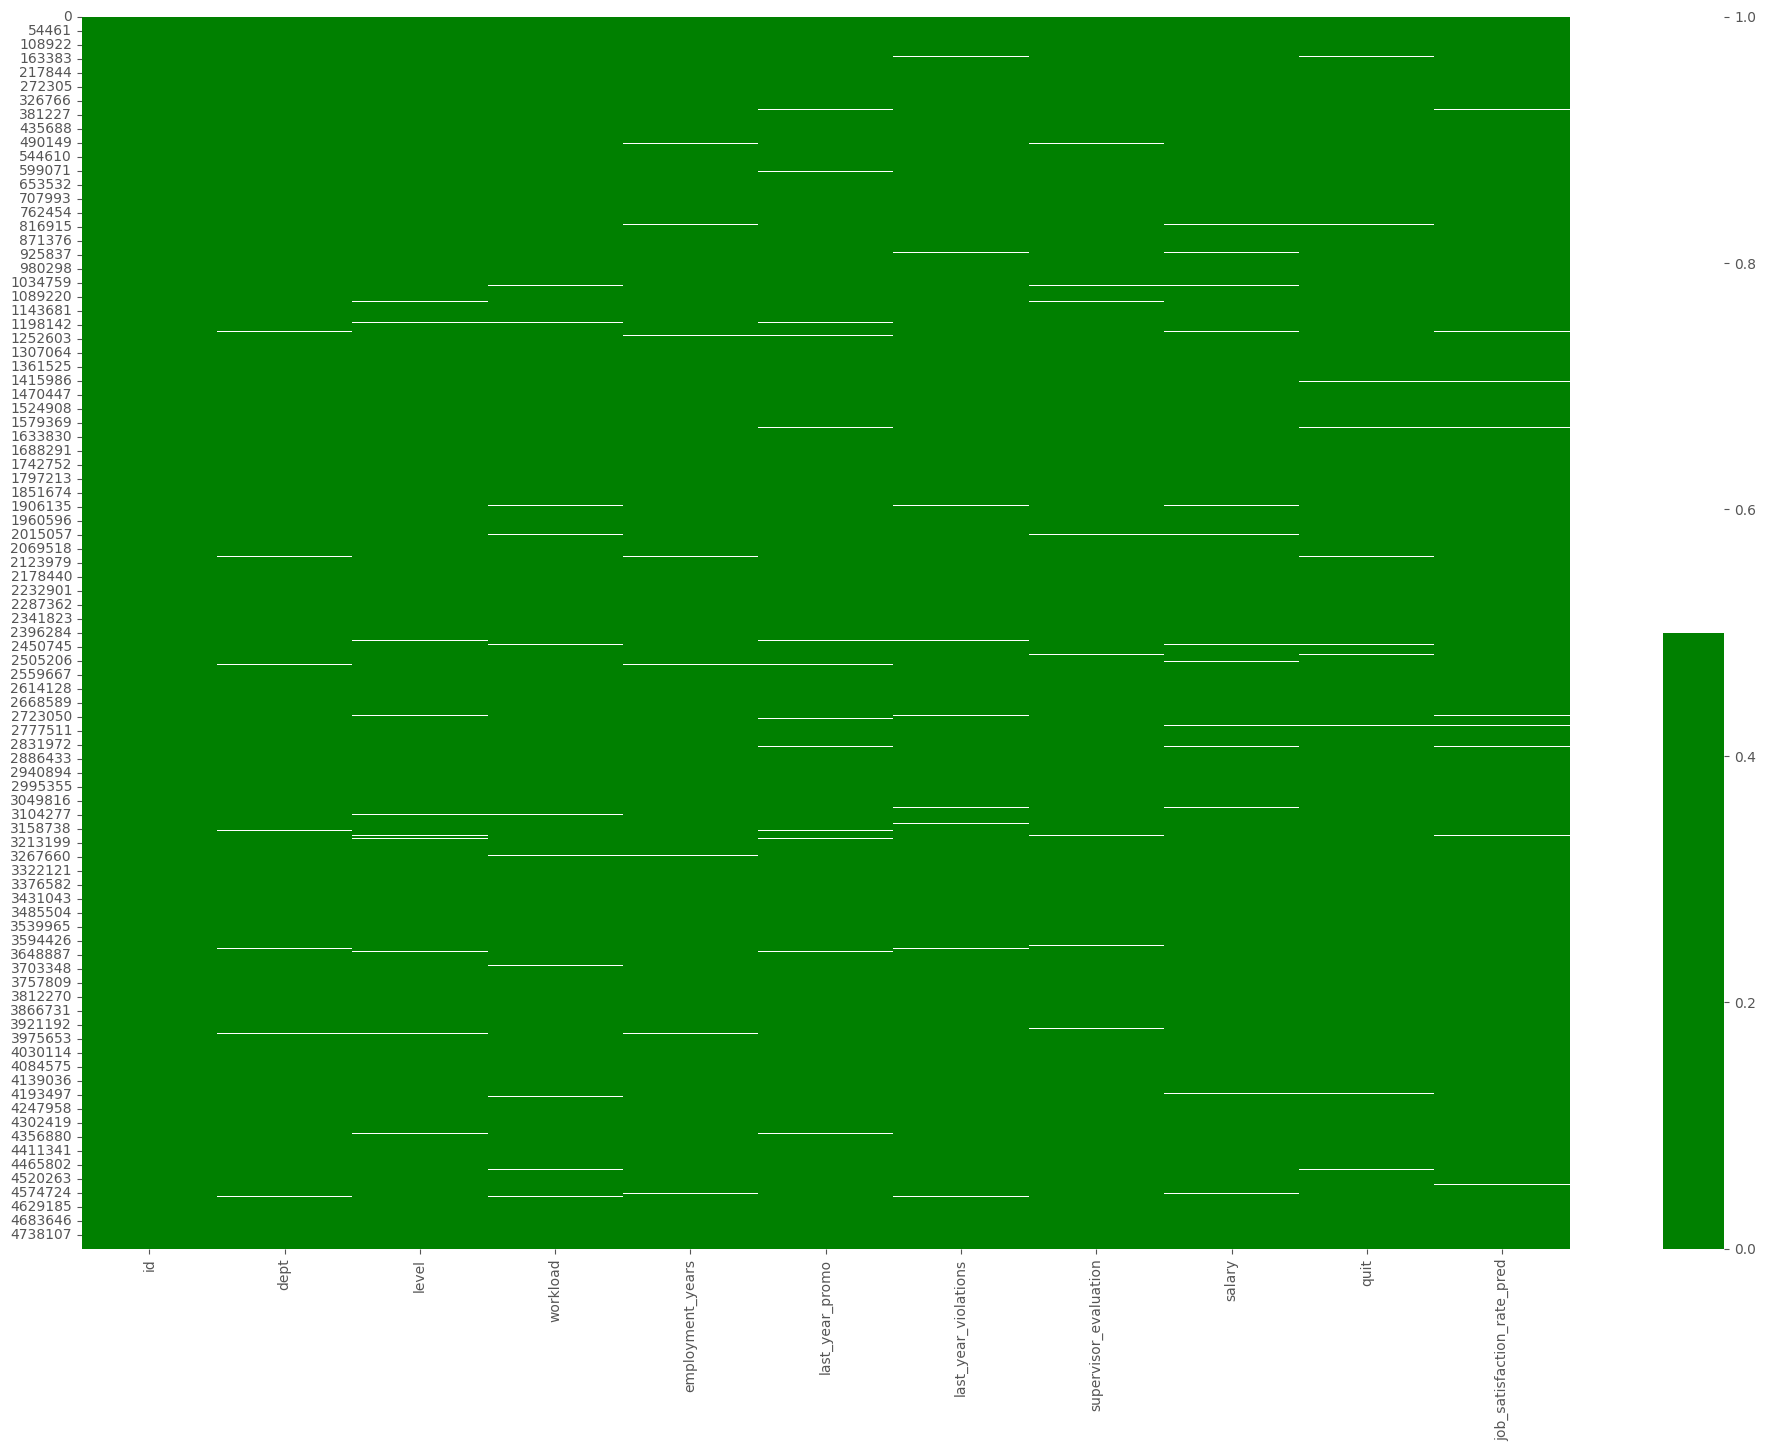

In [ ]:
# построим тепловую карту пропусков
cols = df.columns # Посмотрим пропуски во всех колонках
# Определяем цвета
# Белый - пропущенные данные, зеленый - не пропущенные
colors = ['green', 'white']
a = sns.heatmap(df[cols].isnull(), cmap=sns.color_palette(colors))

По виду тепловой карты понимаем, что пропуском нет только в пером столбце с уникальным идентификатором сотрудника (id), в остальных столбцах они есть в каждом, расположены не равномерно, но совсем пустых неиформативных строк визуально не наблюдается, и в отдельных столбцах их не настолько много, чтобы исключать какой-то признак целиком.

Однако следует отметить, что пропуски есть и в столбце с целевым признаком -  job_satisfaction_rate — уровень удовлетворённости работой, это значит, что строки с данным видом пропусков мы можем впоследствии удалить, т.к. они не несут информации о значении целевой переменной с тем набором параметров, кторые находятся в данных строках.

Остальные пропуски мы позднее заполним или удалим - после выполненного анализа и дальнейшей обработки датасета.

In [ ]:
# Посчитаем абсолютное количество пропусков в каждом столбце
missing_counts = df.isna().sum()
missing_counts

,0
id,0
dept,30499
level,29160
workload,29144
employment_years,28996
last_year_promo,29389
last_year_violations,29076
supervisor_evaluation,29057
salary,30456
quit,29066


Еще раз убедились, что пропуски есть во всех столбцах, кроме первого (id).

In [ ]:
# Теперь отсортируем столбцы по количеству пропусков по убыванию и посчитаем их долю в общем числе значений
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100)
}).sort_values("missing_count", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct
dept,30499,0.636388
salary,30456,0.635491
last_year_promo,29389,0.613227
level,29160,0.608449
workload,29144,0.608115
last_year_violations,29076,0.606696
quit,29066,0.606488
supervisor_evaluation,29057,0.606300
job_satisfaction_rate_pred,29054,0.606237
employment_years,28996,0.605027


Видим, что процент пропусков в каждом признаке составляет от 0,61% до 0,64%. Даже если предположить, что пропущенные значения не пересекаются по строкам, общее количество строк с пропусками не превышает 6,4% от общего размера датасета. Это хорошо, количество пропущенных данных невелико, а значит незначительно влияет на качество модели.

**4. Дубликаты**

**4.1. Полные дубликаты**

In [ ]:
# Полные дубликаты (совпадают ВСЕ значения во всех столбцах)
full_dups_mask = df.duplicated(keep=False)          # True для всех строк-дубликатов
full_dups = df[full_dups_mask].sort_values(df.columns.tolist())

print("Количество строк, являющихся полными дубликатами:", full_dups.shape[0])
print("Количество повторяющихся групп (уникальных дублей):", df.duplicated().sum())

full_dups.head(20)  # посмотреть примеры


Количество строк, являющихся полными дубликатами: 6
Количество повторяющихся групп (уникальных дублей): 3


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate_pred
2959197,396700,it,senior,medium,5.0,yes,no,5.0,380000.0,no,1.3
4033148,396700,it,senior,medium,5.0,yes,no,5.0,380000.0,no,1.3
2172019,596952,it,junior,medium,1.0,yes,no,5.0,225000.0,no,1.3
4199390,596952,it,junior,medium,1.0,yes,no,5.0,225000.0,no,1.3
876120,663159,technology,senior,medium,5.0,yes,no,4.0,365000.0,no,1.3
1947217,663159,technology,senior,medium,5.0,yes,no,4.0,365000.0,no,1.3


In [ ]:
# Удаляем полные дубликаты (совпадают все столбцы)
df = df.drop_duplicates(keep="first").reset_index(drop=True)

print("Новый размер датасета:", df.shape)


Новый размер датасета: (4792510, 11)


**4.2. Частичные дубликаты**

Проанализируем датасет на предмет частичных дубликатов, взяв за уникальный признак id - уникальный идентификатор сотрудника. В данном столбце нет пропусков, посмотрим на предмет повторяющейся информации

In [ ]:
# Дубликаты по id (все строки, где id повторяется)
dup_rows = df[df.duplicated(subset=['id'], keep=False)].sort_values('id')

print("Кол-во строк с повторяющимся id:", dup_rows.shape[0])
print("Кол-во уникальных id, которые повторяются:", dup_rows['id'].nunique())

dup_rows.head(20)  # посмотреть первые дубликаты


Кол-во строк с повторяющимся id: 4723207
Кол-во уникальных id, которые повторяются: 876137


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,...,employment_years_was_missing,employment_years_was_anomaly,salary_was_anomaly,dept_was_missing,level_was_missing,workload_was_missing,supervisor_evaluation_was_missing,last_year_promo_was_missing,last_year_violations_was_missing,quit_was_missing
1885840,1000,sales,middle,medium,2.0,0,0,1.0,180000.0,0,...,0,0,0,0,0,0,0,0,0,0
1740111,1000,finance,junior,medium,1.0,0,0,2.0,225000.0,1,...,0,0,0,0,0,0,0,0,0,0
994538,1000,sales,junior,high,2.0,1,1,2.0,125000.0,0,...,0,0,0,0,0,0,0,0,0,0
1940164,1000,sales,senior,low,5.0,0,0,1.0,280000.0,0,...,0,0,0,0,0,0,0,0,0,0
1075282,1000,sales,junior,medium,1.0,0,0,5.0,110000.0,0,...,0,0,0,0,0,0,0,0,0,0
2528625,1000,finance,senior,low,5.0,0,0,4.0,400000.0,0,...,0,0,0,0,0,0,0,0,0,0
112191,1000,sales,junior,high,1.0,0,0,1.0,150000.0,0,...,0,0,0,0,0,0,0,0,0,0
3391092,1000,technology,junior,medium,1.0,0,0,3.0,220000.0,0,...,0,0,0,0,0,0,0,0,0,0
3516608,1000,marketing,junior,medium,1.0,0,0,1.0,145000.0,1,...,0,0,0,0,0,0,0,0,0,0
4673920,1000,finance,middle,low,1.0,0,0,1.0,260000.0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
id_counts = df["id"].value_counts()
print("Всего уникальных id:", id_counts.size)
print("Повторяющихся id:", (id_counts > 1).sum())
print("Доля строк с повторяющимся id:", df["id"].isin(id_counts[id_counts>1].index).mean()*100)

print("Топ-10 id по количеству строк:")
print(id_counts.head(10))
print("Квантили размера групп id:")
print(id_counts.quantile([0.5,0.9,0.99,0.999]))


Всего уникальных id: 903921
Повторяющихся id: 877371
Доля строк с повторяющимся id: 99.44601054562223
Топ-10 id по количеству строк:
id
7358    33
7007    32
2610    31
8980    31
9353    31
4526    30
6447    30
1262    30
8087    29
7693    29
Name: count, dtype: int64
Квантили размера групп id:
0.500     5.0
0.900     8.0
0.990    13.0
0.999    21.0
Name: count, dtype: float64


In [ ]:
cols = ["dept","level","salary","employment_years","workload","supervisor_evaluation","quit"]
var_by_id = df.groupby("id")[cols].nunique(dropna=False)

# id, где есть изменения хотя бы по одному полю
changed_ids = (var_by_id > 1).any(axis=1)
print("id с разными значениями внутри группы:", changed_ids.sum())
print("Примеры id с изменениями:")
display(var_by_id[changed_ids].head(10))


id с разными значениями внутри группы: 877356
Примеры id с изменениями:


,dept,level,salary,employment_years,workload,supervisor_evaluation,quit
id,,,,,,,
1000,5,3,17,6,3,5,2
1001,6,3,14,4,3,5,2
1002,4,3,14,4,3,3,2
1003,7,2,21,4,3,5,2
1004,6,3,11,3,3,4,2
1005,5,3,17,4,3,5,2
1006,5,2,13,3,3,5,2
1007,4,3,12,4,3,5,2
1008,6,3,16,4,3,5,2


**4.3. Проверка гипотезы о "снимках во времени" ввиду неуникальных id сотрудников**

In [ ]:
g_ey = df.groupby("id")["employment_years"].agg(
    size="size",
    nunique="nunique",
    min_ey="min",
    max_ey="max",
    first_ey="first",
    last_ey="last",
)

g_ey["range_ey"] = g_ey["max_ey"] - g_ey["min_ey"]

print("=== employment_years: диагностика по id ===")
print("Всего id:", len(g_ey))
print("id с несколькими значениями стажа (nunique>1):", (g_ey["nunique"] > 1).sum(),
      f"({(g_ey['nunique'] > 1).mean()*100:.2f}%)")

print("\nРаспределение range_ey (max-min):")
print(g_ey["range_ey"].quantile([0.5, 0.9, 0.99, 0.999]))

# сколько id с "большим" разбросом стажа
for thr in [0, 1, 2, 5, 10]:
    print(f"range_ey > {thr}: {(g_ey['range_ey'] > thr).sum()} ({(g_ey['range_ey'] > thr).mean()*100:.2f}%)")

# проверка направления изменения по порядку строк (прокси времени)
nondecreasing = (g_ey["last_ey"] >= g_ey["first_ey"]).mean() * 100
print(f"\nДоля id, где last_ey >= first_ey (по порядку строк): {nondecreasing:.2f}%")


=== employment_years: диагностика по id ===
Всего id: 903685
id с несколькими значениями стажа (nunique>1): 792567 (87.70%)

Распределение range_ey (max-min):
0.500     3.0
0.900     4.0
0.990     6.0
0.999    10.0
Name: range_ey, dtype: float64
range_ey > 0: 792567 (87.70%)
range_ey > 1: 607672 (67.24%)
range_ey > 2: 463259 (51.26%)
range_ey > 5: 9941 (1.10%)
range_ey > 10: 810 (0.09%)

Доля id, где last_ey >= first_ey (по порядку строк): 70.12%


In [ ]:
g_quit = df.groupby("id")["quit"].agg(
    size="size",
    nunique="nunique",
    min_q="min",
    max_q="max",
    first_q="first",
    last_q="last",
)

print("=== quit: диагностика по id ===")
print("Всего id:", len(g_quit))

only_0 = (g_quit["nunique"] == 1) & (g_quit["min_q"] == 0)
only_1 = (g_quit["nunique"] == 1) & (g_quit["min_q"] == 1)
both_01 = (g_quit["nunique"] == 2) & (g_quit["min_q"] == 0) & (g_quit["max_q"] == 1)

print("id только с quit=0:", only_0.sum(), f"({only_0.mean()*100:.2f}%)")
print("id только с quit=1:", only_1.sum(), f"({only_1.mean()*100:.2f}%)")
print("id с quit=0 и quit=1:", both_01.sum(), f"({both_01.mean()*100:.2f}%)")

# "реверс" по порядку строк (прокси времени)
reversed_order = (g_quit["first_q"] == 1) & (g_quit["last_q"] == 0)
print("\nid где first quit=1, а last quit=0 (по порядку строк):",
      reversed_order.sum(), f"({reversed_order.mean()*100:.2f}%)")


=== quit: диагностика по id ===
Всего id: 903685
id только с quit=0: 239701 (26.52%)
id только с quit=1: 14372 (1.59%)
id с quit=0 и quit=1: 649612 (71.88%)

id где first quit=1, а last quit=0 (по порядку строк): 75988 (8.41%)


In [ ]:
# средний стаж отдельно по quit
print(df.groupby("quit")["employment_years"].agg(["count", "mean", "median"]).round(3))

# для id, у которых встречаются и quit=0 и quit=1:
ids_both = g_quit[(g_quit["nunique"] == 2) & (g_quit["min_q"] == 0) & (g_quit["max_q"] == 1)].index
tmp = df[df["id"].isin(ids_both)].groupby(["id", "quit"])["employment_years"].mean().unstack()

tmp["diff_ey_quit1_minus_quit0"] = tmp[1] - tmp[0]
print("\nРазница среднего стажа внутри id (quit=1 минус quit=0):")
print(tmp["diff_ey_quit1_minus_quit0"].describe().round(3))


        count   mean  median
quit                        
0     3543958  1.956     1.0
1     1206797  1.643     1.0

Разница среднего стажа внутри id (quit=1 минус quit=0):
count    649612.000
mean         -0.314
std           1.197
min         -19.000
25%          -1.000
50%          -0.375
75%           0.250
max          15.333
Name: diff_ey_quit1_minus_quit0, dtype: float64


In [ ]:
cols = ["dept", "level", "workload", "supervisor_evaluation"]
var_cat = df.groupby("id")[cols].nunique(dropna=False)

print("Доля id с изменениями по dept:", (var_cat["dept"] > 1).mean()*100)
print("Доля id с изменениями по level:", (var_cat["level"] > 1).mean()*100)
print("Доля id с изменениями по workload:", (var_cat["workload"] > 1).mean()*100)
print("Доля id с изменениями по supervisor_evaluation:", (var_cat["supervisor_evaluation"] > 1).mean()*100)


Доля id с изменениями по dept: 94.77837963449653
Доля id с изменениями по level: 83.8019885247625
Доля id с изменениями по workload: 85.73440966708532
Доля id с изменениями по supervisor_evaluation: 92.45234788670831


**Вывод по п.4.3.**

В ходе проверки неявных (частичных) дубликатов было установлено, что поле `id` не является уникальным ключом строки. Большинство сотрудников представлено в датасете несколькими записями, при этом внутри одного `id` значения признаков часто различаются. Это подтверждает, что повторяющиеся `id` - не простое дублирование строк, а набор разных наблюдений, относящихся к одной и той же сущности (сотруднику), либо результат объединения данных из разных срезов/ источников.

Анализ трудового стажа (`employment_years`) показал, что у 87.7% сотрудников встречается более одного значения стажа. При этом разброс значений внутри `id` чаще всего умеренный: медианный диапазон (max-min) равен 3, у 90% сотрудников он не превышает 4, а большие расхождения встречаются редко (range > 5 лишь у 1.1% id, range > 10 - у 0.09%). Такие результаты согласуются с гипотезой о повторных наблюдениях, однако порядок строк не может интерпретироваться как временной: лишь в 70.1% случаев последнее значение стажа (в порядке следования строк) не меньше первого, что говорит о перемешанности записей или отсутствии явной хронологии.

Дополнительная проверка признака `quit` также подтверждает отсутствие стабильного “финального статуса” сотрудника в пределах `id`. У 71.9% сотрудников встречаются оба значения `quit` (0 и 1), а доля случаев, когда первая запись имеет `quit=1`, а последняя `quit=0`, составляет 8.4%. Это означает, что строки внутри одного `id` не упорядочены по времени, а сам признак `quit` может отражать состояние на момент конкретной записи либо содержать шум, поэтому интерпретировать его как однозначный итог “уволился/не уволился” для сотрудника нельзя.

Также было выявлено, что категориальные и ординальные признаки внутри одного `id` меняются очень часто: доля сотрудников с несколькими значениями составляет 94.8% по `dept`, 83.8% по `level`, 85.7% по `workload` и 92.5% по `supervisor_evaluation`. Такое количество изменений значительно превышает ожидаемую частоту переводов/повышений в реальных данных и дополнительно указывает на мультизаписи по сотруднику или неоднородность источника данных.

С учётом отсутствия временной метки и высокой доли многократных записей для одного `id`, строки с повторяющимися `id` не удалялись как дубликаты, чтобы не потерять большую часть наблюдений и не исказить распределения признаков. Вместо этого для корректного моделирования учтён риск утечки данных: при разбиении на обучающую и тестовую выборки необходимо использовать групповое разбиение по `id`, чтобы записи одного и того же сотрудника не попадали одновременно и в train, и в test. Это позволяет сохранить максимум информации и одновременно обеспечить корректную оценку качества модели.


**Вывод по п.4**

Полные дубликаты (строки, полностью совпадающие по всем признакам) были обнаружены и удалены стандартным способом с помощью drop_duplicates, чтобы исключить повторяющиеся записи, не несущие дополнительной информации.

При анализе данных также выявлены неявные (частичные) дубликаты, связанные с повторяющимися значениями поля id. Оказалось, что id не является уникальным ключом строки: 99.45% строк относятся к сотрудникам, которые встречаются в датасете более одного раза. При этом медианный сотрудник представлен пятью записями, а для большинства повторяющихся id значения атрибутов внутри группы различаются (например, отдел, уровень должности, зарплата, стаж, нагрузка и т.д.).

На основании этих наблюдений сделан вывод, что повторяющиеся id с различающимися признаками, вероятнее всего, отражают несколько наблюдений одного и того же сотрудника (например, изменения условий работы или состояния сотрудника во времени), а не простую ошибку дублирования строк. Так как в датасете отсутствует временная метка, корректно определить «последнюю» или «актуальную» запись для каждого сотрудника невозможно, поэтому прямое сведение данных к одной строке на id может привести к потере значимой информации.

В рамках подготовки датасета к моделированию такие записи не удалялись как дубликаты. Однако при построении модели учитывается риск утечки данных: один и тот же сотрудник не должен одновременно попадать в обучающую и тестовую выборки. Поэтому разбиение данных на train/test выполняется по группам id (group split), что позволяет избежать попадания записей одного сотрудника в разные части выборки и обеспечивает более корректную оценку качества модели.

**5. Перешифровка бинарных признаков**

In [ ]:
# Шифруем бинарные признаки "last_year_promo", "last_year_violations", "quit" (Yes - 1, No - 0)

bin_cols = ["last_year_promo", "last_year_violations", "quit"]
mapping = {"Yes": 1, "No": 0}

for c in bin_cols:
    # приводим к строкам, чистим пробелы/регистр, но NaN оставляем
    s = df[c].astype("string").str.strip().str.title()  # "yes"->"Yes", "no"->"No"
    df[c] = s.map(mapping).astype("Int64")  # Int64 сохраняет <NA>


Проверяем, что бинарные признаки имеют вид 0/ 1:

In [ ]:
df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate_pred
0,690679,finance,junior,medium,1.0,0,0,4.0,175000.0,1,1.156844
1,125148,hr,senior,low,3.0,0,0,2.0,280000.0,0,0.745757
2,311009,sales,junior,high,2.0,0,0,1.0,105000.0,0,0.581074
3,908488,finance,junior,medium,1.0,0,0,2.0,100000.0,0,0.671288
4,756857,technology,junior,medium,1.0,0,0,2.0,100000.0,1,0.347873


Бинарные признаки перешифрованы. сними можно выполнять расчеты. К категориальным и каечственным без порядка вернемся позже.

**6. "Подозрительные" и аномальные значения**

Посмотрим на подозрительные значения по числовым признакам - длительности работы в компании (employment_years) и ежемесячнной заработной плате (salary). Стаж работы должен лежать в пределах от 0 до 35 (т.к. Альфа-Банк основан в 1990 году, т.е. компании всего 35 лет), зарплата точно не может быть отрицательной и запределно большой (посмотрим, сколько значений меньше 0 и больше 1_000_000 и подрегулируем границы от увиденного).

In [ ]:
# на всякий случай приводим к числам
df["employment_years"] = pd.to_numeric(df["employment_years"], errors="coerce")
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")

n = len(df)

# Маски аномалий по заданным условиям
mask_ey_lt0  = df["employment_years"].notna() & (df["employment_years"] < 0)
mask_ey_gt35 = df["employment_years"].notna() & (df["employment_years"] > 35)

mask_sal_lt30k  = df["salary"].notna() & (df["salary"] < 0)
mask_sal_gt400k = df["salary"].notna() & (df["salary"] > 1000_000)

# Сводка (кол-во + доля от всего датасета)
stats = pd.DataFrame({
    "count": [
        mask_ey_lt0.sum(), mask_ey_gt35.sum(),
        mask_sal_lt30k.sum(), mask_sal_gt400k.sum()
    ],
    "pct_of_all_rows": [
        mask_ey_lt0.mean() * 100, mask_ey_gt35.mean() * 100,
        mask_sal_lt30k.mean() * 100, mask_sal_gt400k.mean() * 100
    ]
}, index=[
    "employment_years < 0",
    "employment_years > 35",
    "salary < 0",
    "salary > 1000000"
])

print(stats)

# Дополнительно: сколько уникальных строк попадает хотя бы в один фильтр
mask_any = mask_ey_lt0 | mask_ey_gt35 | mask_sal_lt30k | mask_sal_gt400k
print("\nСтрок с хотя бы одной такой аномалией:", mask_any.sum(),
      f"({mask_any.mean()*100:.4f}%)")

# Если хочешь посмотреть примеры строк (лучше не печатать слишком много)
cols_show = ["id", "dept", "level", "employment_years", "salary", "quit", "job_satisfaction_rate_pred"]

print("\nПримеры employment_years < 0:")
display(df.loc[mask_ey_lt0, cols_show].head(10))

print("\nПримеры employment_years > 35:")
display(df.loc[mask_ey_gt35, cols_show].head(10))

print("\nПримеры salary < 0:")
display(df.loc[mask_sal_lt30k, cols_show].head(10))

print("\nПримеры salary > 1000000:")
display(df.loc[mask_sal_gt400k, cols_show].head(10))


                       count  pct_of_all_rows
employment_years < 0    9501         0.198247
employment_years > 35   4937         0.103015
salary < 0             15049         0.314011
salary > 1000000       12668         0.264329

Строк с хотя бы одной такой аномалией: 37230 (0.7768%)

Примеры employment_years < 0:


,id,dept,level,employment_years,salary,quit,job_satisfaction_rate_pred
151,209056,it,junior,-100.0,105000.0,0,0.718415
478,759945,sales,junior,-100.0,115000.0,0,0.781095
485,507023,finance,junior,-20.0,140000.0,1,0.734877
710,834281,technology,junior,-100.0,130000.0,0,0.523725
748,722532,sales,middle,-20.0,135000.0,0,0.968255
916,835910,technology,middle,-20.0,235000.0,0,1.025480
1927,146053,sales,junior,-50.0,120000.0,0,0.768893
2419,906060,finance,junior,-50.0,195000.0,0,1.019812
3295,533847,hr,junior,-50.0,120000.0,0,1.034172
3741,234147,sales,junior,-100.0,90000.0,0,0.848308



Примеры employment_years > 35:


,id,dept,level,employment_years,salary,quit,job_satisfaction_rate_pred
1132,652176,finance,senior,100.0,4190000.0,1,1.300000
1452,746465,technology,senior,60.0,2570000.0,0,1.067977
1865,477773,finance,middle,50.0,1940000.0,0,1.024982
3032,530525,it,middle,100.0,3445000.0,1,1.093052
4680,1214,technology,middle,100.0,3165000.0,0,0.839938
6071,617903,hr,middle,50.0,1585000.0,0,0.933586
6438,964209,sales,middle,60.0,1935000.0,0,0.781451
9170,963164,sales,middle,50.0,1610000.0,0,0.836996
9194,540682,finance,senior,200.0,7430000.0,0,1.246471
10456,294378,hr,middle,100.0,3045000.0,0,0.721113



Примеры salary < 0:


,id,dept,level,employment_years,salary,quit,job_satisfaction_rate_pred
369,270668,marketing,senior,4.0,-50000.0,0,0.645649
838,157287,hr,senior,5.0,-100000.0,0,1.032817
1070,740224,technology,middle,4.0,-200000.0,0,1.126428
1433,132459,hr,junior,1.0,-50000.0,0,1.017553
1694,453284,finance,junior,1.0,-100000.0,0,1.006590
2190,717176,hr,middle,1.0,-50000.0,0,0.508691
2222,702661,finance,junior,2.0,-200000.0,0,0.704661
2236,954218,sales,middle,3.0,-200000.0,0,0.727480
2315,128174,finance,junior,2.0,-100000.0,0,1.077661
2856,844642,hr,junior,1.0,-500000.0,0,0.662553



Примеры salary > 1000000:


,id,dept,level,employment_years,salary,quit,job_satisfaction_rate_pred
165,941386,finance,junior,1.0,5855000.0,0,1.087432
411,999165,sales,junior,1.0,1485000.0,0,0.866937
1132,652176,finance,senior,100.0,4190000.0,1,1.300000
1452,746465,technology,senior,60.0,2570000.0,0,1.067977
1865,477773,finance,middle,50.0,1940000.0,0,1.024982
2020,977439,technology,junior,1.0,1900000.0,0,1.002931
2281,891874,finance,junior,1.0,1955000.0,0,1.126804
3032,530525,it,middle,100.0,3445000.0,1,1.093052
4138,349975,hr,junior,1.0,5255000.0,0,0.306959
4638,273702,hr,junior,1.0,1685000.0,0,0.454562


Посмотрим. если зарплаты от 0 до 30 000

In [ ]:
# Строки с зарплатой от 0 до 30000 (включительно)
mask_sal_0_30k = df["salary"].notna() & df["salary"].between(0, 30_000)

print("Строк с salary в [0; 30000]:", mask_sal_0_30k.sum(),
      f"({mask_sal_0_30k.mean()*100:.4f}%)")

cols_show = ["id", "dept", "level", "employment_years", "salary", "quit", "job_satisfaction_rate_pred"]
display(df.loc[mask_sal_0_30k, cols_show].head(20))


Строк с salary в [0; 30000]: 0 (0.0000%)


,id,dept,level,employment_years,salary,quit,job_satisfaction_rate_pred


Зарплат менее 30 000 нет.

Посмотрим, есть ли зарплаты в интервале от 500_000 до 1_000_000

In [ ]:
# Строки с зарплатой от 500000 до 1000000 (включительно)
mask_sal_500k_1m = df["salary"].notna() & df["salary"].between(500_000, 1_000_000)

print("Строк с salary в [500000; 1000000]:", mask_sal_500k_1m.sum(),
      f"({mask_sal_500k_1m.mean()*100:.4f}%)")

cols_show = ["id", "dept", "level", "employment_years", "salary", "quit", "job_satisfaction_rate_pred"]
display(df.loc[mask_sal_500k_1m, cols_show].head(20))


Строк с salary в [500000; 1000000]: 78082 (1.6293%)


,id,dept,level,employment_years,salary,quit,job_satisfaction_rate_pred
9,264522,finance,senior,3.0,550000.0,0,1.293812
31,672901,it,senior,3.0,510000.0,0,1.063583
118,709392,finance,senior,4.0,520000.0,0,1.065662
299,370070,finance,senior,4.0,545000.0,0,1.295518
462,728496,it,senior,4.0,545000.0,0,1.242342
504,396068,finance,senior,6.0,665000.0,0,0.955374
533,937797,finance,senior,5.0,510000.0,1,0.980060
582,424469,finance,senior,4.0,515000.0,0,1.300000
609,602287,technology,senior,4.0,530000.0,0,1.264995
641,606597,it,senior,3.0,530000.0,0,1.300000


Зарплаты в диапазоне от 500_000 до 1_000_000 есть и соответствуют должностям уровня senior. Примем их как реально существующие.

In [ ]:
# на всякий случай приводим к числам
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df["employment_years"] = pd.to_numeric(df["employment_years"], errors="coerce")

def audit_numeric(s, name):
    print(f"\n=== {name} ===")
    print("count:", s.count(), "missing:", s.isna().sum())
    print("min/max:", s.min(), s.max())
    qs = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
    print("quantiles:\n", s.quantile(qs))

audit_numeric(df["employment_years"], "employment_years")
audit_numeric(df["salary"], "salary")

# невозможные базовые значения
bad_ey = df["employment_years"].notna() & (df["employment_years"] < 0)
bad_salary = df["salary"].notna() & (df["salary"] <= 0)

print("\nНевозможные employment_years < 0:", bad_ey.sum(), f"({bad_ey.mean()*100:.4f}%)")
print("Невозможные salary <= 0:", bad_salary.sum(), f"({bad_salary.mean()*100:.4f}%)")



=== employment_years ===
count: 4763514 missing: 28996
min/max: -100.0 200.0
quantiles:
 0.001   -50.0
0.010     1.0
0.050     1.0
0.500     1.0
0.950     5.0
0.990     5.0
0.999    50.0
Name: employment_years, dtype: float64

=== salary ===
count: 4762054 missing: 30456
min/max: -500000.0 7925000.0
quantiles:
 0.001    -200000.0
0.010      70000.0
0.050      95000.0
0.500     190000.0
0.950     410000.0
0.990     545000.0
0.999    2985000.0
Name: salary, dtype: float64

Невозможные employment_years < 0: 9501 (0.1982%)
Невозможные salary <= 0: 15049 (0.3140%)


# **Вариант А_Расчет метрик_до удаления строк**

**Для сравнения вычислим метрики до удаления строк с аномальными значениями, просто исключив их из расчетных диапазонов (чтобы из=за удаления строк не "выпадали" данные в других столбцах. Потом почистим датасет от аномалий, заполинм пропуски и посчитаем метрики еще раз. Затем сравним результаты и сделаем выводы, насколько удаление строк влияет на показатели.**

Итак, вычислим медианный трудовой стаж, среднюю заработную плату и процент уволившихся, взяв для этого только релевантные значения из соответствующих столбцов.

1. Вычисление медианного трудового стажа (employment_years) для каждого уровня должности (junior, middle, senior). Медиану считаем по непустым значениям в диапазоне от 0 до 35 включительно.

In [ ]:
# фильтр: стаж не пустой и в [0; 35]
mask_ey_ok = df["employment_years"].notna() & df["employment_years"].between(0, 35)

median_by_level = (
    df.loc[mask_ey_ok]
      .groupby("level", dropna=False)["employment_years"]
      .median()
      .reindex(["junior", "middle", "senior"])
)

print(median_by_level)


level
junior    1.0
middle    2.0
senior    5.0
Name: employment_years, dtype: float64


2. Вычисление средней заработной платы (salary) для каждого уровня должности (junior, middle, senior) - общую и по отделам. Интервал заработной платы берем более 30_000 и менее 1_000_000.

In [ ]:
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
mask_sal_ok = df["salary"].notna() & df["salary"].gt(30_000) & df["salary"].lt(1_000_000)

level_order = ["junior", "middle", "senior"]

# Средняя зарплата по уровню (округление до целых)
avg_salary_by_level = (
    df.loc[mask_sal_ok]
      .groupby("level")["salary"]
      .mean()
      .reindex(level_order)
      .round(0)
      .astype("Int64")
)

print("Средняя зарплата по уровню (целые):")
print(avg_salary_by_level)

# Средняя зарплата по уровню и отделу (округление до целых)
pivot_level_dept = (
    df.loc[mask_sal_ok]
      .groupby(["level", "dept"])["salary"]
      .mean()
      .unstack("dept")
      .reindex(level_order)
      .round(0)
      .astype("Int64")
)

print("\nСредняя зарплата по уровню и отделу (целые):")
display(pivot_level_dept)

Средняя зарплата по уровню (целые):
level
junior    163131
middle    252570
senior    381905
Name: salary, dtype: Int64

Средняя зарплата по уровню и отделу (целые):


dept,finance,hr,it,marketing,sales,technology
level,,,,,,
junior,199105,139429,188401,107842,148840,178789
middle,315989,203183,295278,135451,221290,277497
senior,476504,291289,443109,268067,320714,413560


3. Нахождение отдела с наибольшим процентом уволившихся. Для этого используем все непустые ячейки столбца quit.

In [ ]:
# quit уже 0/1 (Int64) + <NA>
df_q = df[df["quit"].notna()]

# доля уволившихся = сумма единиц / кол-во непустых значений
quit_rate_by_dept = df_q.groupby("dept")["quit"].sum() / df_q.groupby("dept")["quit"].count()

# в проценты
quit_pct_by_dept = quit_rate_by_dept * 100

top_dept = quit_pct_by_dept.idxmax()
top_pct = quit_pct_by_dept.loc[top_dept]

print("Отдел с наибольшим процентом уволившихся:", top_dept)
print(f"Процент уволившихся: {top_pct:.2f}%")

display(quit_pct_by_dept.sort_values(ascending=False).round(2))


Отдел с наибольшим процентом уволившихся: hr
Процент уволившихся: 66.72%


,quit
dept,
hr,66.72
marketing,56.01
sales,21.1
it,19.58
technology,9.78
finance,6.41


# **7. Теперь поработаем с пропусками, дубликатами и аномалиями для подготовки датасета к моделированию.**

**Для начала проанализируем значения нашей целевой переменной. Посмотрим сколько в ней пропусков и значений за пределами диапазона [0; 1].**

In [ ]:
col = "job_satisfaction_rate_pred"

# на всякий случай приводим таргет к числам
df[col] = pd.to_numeric(df[col], errors="coerce")

# сколько строк всего + пропуски и их доля
n_total = len(df)
n_missing = df[col].isna().sum()
print(f"Всего строк: {n_total}")
print(f"Пропусков в {col}: {n_missing} ({n_missing / n_total * 100:.4f}%)")

def audit_numeric(s, name):
    print(f"\n=== {name} ===")
    print("count:", s.count(), "missing:", s.isna().sum())
    print("min/max:", s.min(), s.max())
    qs = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
    print("quantiles:\n", s.quantile(qs))

audit_numeric(df[col], col)

# значения вне допустимого диапазона [0; 1]
y = df[col]
bad_lt0 = y.notna() & (y < 0)
bad_gt1 = y.notna() & (y > 1)
bad_oob = y.notna() & ~y.between(0, 1)

print("\nЗначения ниже 0:", bad_lt0.sum(), f"({bad_lt0.mean()*100:.4f}%)")
print("Значения выше 1:", bad_gt1.sum(), f"({bad_gt1.mean()*100:.4f}%)")
print("Всего вне [0; 1]:", bad_oob.sum(), f"({bad_oob.mean()*100:.4f}%)")


Всего строк: 4792510
Пропусков в job_satisfaction_rate_pred: 29054 (0.6062%)

=== job_satisfaction_rate_pred ===
count: 4763456 missing: 29054
min/max: -10.0 10.0
quantiles:
 0.001   -0.338258
0.010    0.211550
0.050    0.398960
0.500    0.841467
0.950    1.234599
0.990    1.300000
0.999    2.070000
Name: job_satisfaction_rate_pred, dtype: float64

Значения ниже 0: 7900 (0.1648%)
Значения выше 1: 1322324 (27.5915%)
Всего вне [0; 1]: 1330224 (27.7563%)


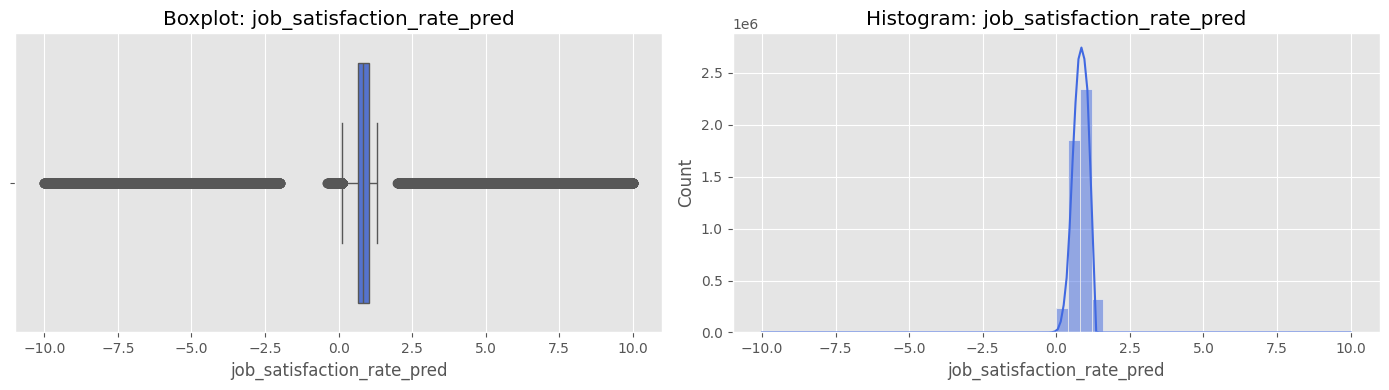

In [ ]:
col = "job_satisfaction_rate_pred"

# берем только непустые значения
x = df[col].dropna()

# чтобы графики были быстрыми на 4.8M строк - можно сэмпл
# x = x.sample(n=300_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1) Boxplot
sns.boxplot(x=x, ax=axes[0], color="royalblue")
axes[0].set_title(f"Boxplot: {col}")
axes[0].set_xlabel(col)

# 2) Histogram + KDE
sns.histplot(x, bins=50, kde=True, ax=axes[1], color="royalblue")
axes[1].set_title(f"Histogram: {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


Так как пропусков в целевой переменной относительно немного (0,61%), а значения признаков без ее итогового значения - неинформативны, то строки с пропусками job_satisfaction_rate_pred можно удалить.

In [ ]:
df = df.dropna(subset=['job_satisfaction_rate_pred'])
print('Размер датасета (количество строк, столбцов):', df.shape)

Размер датасета (количество строк, столбцов): (4763456, 11)


Посчитаем количество "вылетов" за пороговые значения:

In [ ]:
col = "job_satisfaction_rate_pred"
y = pd.to_numeric(df[col], errors="coerce")

thresholds = [1.0, 1.01, 1.05, 1.10, 1.20, 1.30, 2.0, 10.0]
for t in thresholds:
    print(f"> {t}: {(y > t).sum():,}  ({(y > t).mean()*100:.2f}%)")

neg_thresholds = [0.0, -0.01, -0.05, -0.1, -1.0, -10.0]
for t in neg_thresholds:
    print(f"< {t}: {(y < t).sum():,}  ({(y < t).mean()*100:.4f}%)")


> 1.0: 1,322,324  (27.76%)
> 1.01: 1,258,632  (26.42%)
> 1.05: 1,011,749  (21.24%)
> 1.1: 734,328  (15.42%)
> 1.2: 325,224  (6.83%)
> 1.3: 4,801  (0.10%)
> 2.0: 4,800  (0.10%)
> 10.0: 0  (0.00%)
< 0.0: 7,900  (0.1658%)
< -0.01: 7,482  (0.1571%)
< -0.05: 6,332  (0.1329%)
< -0.1: 5,468  (0.1148%)
< -1.0: 4,756  (0.0998%)
< -10.0: 0  (0.0000%)


Расчеты и визуализации показыыают, что достаточно больше количество значений целевой переменной (27,6%) хоть и не намного, но превышают верхнюю границу диапазона, равную 1. Дляя приведения целевой переменной в диапазон [0; 1] удалим немногочисленные отдаленные выбросы (значения меньше 0 и больше 1,3), а правый "хвост" значений 1-1,3 "сожмем" в диапазон 0,9-1,0.

In [ ]:
col = "job_satisfaction_rate_pred"

# на всякий случай приводим к числам
df[col] = pd.to_numeric(df[col], errors="coerce")
y = df[col]

# 1) удаляем только явные выбросы (пропусков уже нет)
mask_keep = (y >= 0) & (y <= 1.3)
df = df.loc[mask_keep].copy()

y = df[col]

# 2) сжимаем хвост (1..1.3) в (0.9..1.0), сохраняя порядок
delta = 0.10  # ширина коридора у 1
mask_tail = y > 1

df.loc[mask_tail, col] = (1 - delta) + delta * (y.loc[mask_tail] - 1) / (1.3 - 1)

# 3) финальная гарантия диапазона
df[col] = df[col].clip(0, 1)

print("Осталось строк:", len(df))
print("min/max:", df[col].min(), df[col].max())
print("Вне [0;1]:", (~df[col].between(0, 1)).sum())


Осталось строк: 4750755
min/max: 2.9874e-06 1.0
Вне [0;1]: 0


Теперь еще раз посмотрим на оставшиеся пропуски после удаления части строк с неинформативной целевой переменной

In [ ]:
# Теперь отсортируем столбцы по количеству пропусков по убыванию и посчитаем их долю в общем числе значений
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100)
}).sort_values("missing_count", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct
salary,25926,0.545724
dept,25840,0.543914
last_year_promo,25141,0.529200
level,24810,0.522233
employment_years,24757,0.521117
workload,24748,0.520928
last_year_violations,24722,0.520380
quit,24685,0.519602
supervisor_evaluation,24669,0.519265


В оставшихся столбцах количество пропусков немного уменьшилось - до 0,52-0,55%, т.к. в удаленных строках пропуски в целевой переменной были не единственными.

**Поработаем с количественными признаками - длительностью работы в компании ( в годах) (employment_years) и ежемесячной заработной платой (salary).**

Выше мы уже принимали решение, что аномальными для стажа считаем значения меньше 0 и более 35, а для зарплаты - меньше 30_000 и более 1_000_000. Посчитаем количество таких аномалий в каждом признаке.

In [ ]:
# на всякий случай приводим к числам
df["employment_years"] = pd.to_numeric(df["employment_years"], errors="coerce")
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")

n = len(df)

# стаж: <0 и >35
mask_ey_lt0  = df["employment_years"].notna() & (df["employment_years"] < 0)
mask_ey_gt35 = df["employment_years"].notna() & (df["employment_years"] > 35)

# зарплата: <30000 и >1000000
mask_sal_lt30k = df["salary"].notna() & (df["salary"] < 30_000)
mask_sal_gt1m  = df["salary"].notna() & (df["salary"] > 1_000_000)

stats = pd.DataFrame({
    "count": [
        mask_ey_lt0.sum(), mask_ey_gt35.sum(),
        mask_sal_lt30k.sum(), mask_sal_gt1m.sum()
    ],
    "pct_of_all_rows": [
        mask_ey_lt0.mean() * 100, mask_ey_gt35.mean() * 100,
        mask_sal_lt30k.mean() * 100, mask_sal_gt1m.mean() * 100
    ]
}, index=[
    "employment_years < 0",
    "employment_years > 35",
    "salary < 30000",
    "salary > 1000000"
])

print("Всего строк:", n)
print(stats)

# сколько уникальных строк попадает хотя бы в один из фильтров
mask_any = mask_ey_lt0 | mask_ey_gt35 | mask_sal_lt30k | mask_sal_gt1m
print("\nСтрок с хотя бы одной аномалией:", mask_any.sum(),
      f"({mask_any.mean()*100:.4f}%)")


Всего строк: 4750755
                       count  pct_of_all_rows
employment_years < 0    9417         0.198221
employment_years > 35   4892         0.102973
salary < 30000         14909         0.313824
salary > 1000000       12565         0.264484

Строк с хотя бы одной аномалией: 36898 (0.7767%)


Ликвидируем аномалии и пропуски в количественных признаках по следующему алгоритму: сначала аномалии превращаем в пропуски NaN, затем все пропущенные значения заполняем медианой по группе уровень должности+ отдел, если один из параметров не заполнен - то только по уровню должности, если ее нет - тогда медианой по всему столбцу. Это позволит не выбрасывать целые строки с данными, макисмлаьно сохранив информацию о других признаках для моделирования.

Медиана же используется вместо средней, так как распределение количественных признаков имеет смещение (не является нормальным).

In [ ]:
# 0) Приведение типов
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df["employment_years"] = pd.to_numeric(df["employment_years"], errors="coerce")

# 1) Флаги пропусков (до заполнения)
df["salary_was_missing"] = df["salary"].isna().astype("Int64")
df["employment_years_was_missing"] = df["employment_years"].isna().astype("Int64")

# 2) Флаги аномалий по заданным правилам
# стаж: [0;35], зарплата: (30_000;1_000_000)
df["employment_years_was_anomaly"] = (
    df["employment_years"].notna() & ~df["employment_years"].between(0, 35)
).astype("Int64")

df["salary_was_anomaly"] = (
    df["salary"].notna() & ~df["salary"].between(30_000, 1_000_000)
).astype("Int64")

# 3) Аномалии -> NaN (чтобы заполнялись вместе с пропусками)
df.loc[df["employment_years_was_anomaly"] == 1, "employment_years"] = np.nan
df.loc[df["salary_was_anomaly"] == 1, "salary"] = np.nan

# 4) Заполнение пропусков/аномалий: (level, dept) -> level -> global median
# Важно: группы, где level или dept пропущены, автоматически дадут NaN,
# поэтому второй и третий шаги подстрахуют.

# salary
df["salary"] = df["salary"].fillna(df.groupby(["level", "dept"])["salary"].transform("median"))
df["salary"] = df["salary"].fillna(df.groupby("level")["salary"].transform("median"))
df["salary"] = df["salary"].fillna(df["salary"].median())

# employment_years
df["employment_years"] = df["employment_years"].fillna(df.groupby(["level", "dept"])["employment_years"].transform("median"))
df["employment_years"] = df["employment_years"].fillna(df.groupby("level")["employment_years"].transform("median"))
df["employment_years"] = df["employment_years"].fillna(df["employment_years"].median())

# 5) (опционально) контроль: должно не остаться NaN
print("salary missing after:", df["salary"].isna().sum())
print("employment_years missing after:", df["employment_years"].isna().sum())

# 6) (опционально) контроль диапазонов после заполнения
print("salary min/max:", df["salary"].min(), df["salary"].max())
print("employment_years min/max:", df["employment_years"].min(), df["employment_years"].max())


salary missing after: 0
employment_years missing after: 0
salary min/max: 40000.0 995000.0
employment_years min/max: 1.0 20.0


Обработка пропусков у качественных, ординальныхх (качественных с категориями) и бинарных признаков. Для dept - метка неизвестного значения unknown (чтобы не удалять строки), для ординальных и бинарных - мода (по возможности - по группам по отделам и должностям.

In [ ]:
# 1) КАТЕГОРИАЛЬНЫЙ: dept
df["dept_was_missing"] = df["dept"].isna().astype("Int64")
df["dept"] = df["dept"].astype("string").str.strip().str.lower().fillna("unknown")

# 2) ОРДИНАЛЬНЫЙ: level
#    (сначала заполним level, чтобы потом использовать (level, dept) для других)
df["level_was_missing"] = df["level"].isna().astype("Int64")

mode_level_by_dept = df.groupby("dept")["level"].transform(
    lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else pd.NA
)
df["level"] = df["level"].fillna(mode_level_by_dept)

global_level_mode = df["level"].dropna().mode()
df["level"] = df["level"].fillna(global_level_mode.iloc[0] if not global_level_mode.empty else "unknown")

# 3) ОРДИНАЛЬНЫЕ: workload, supervisor_evaluation
#    (мода по (level, dept) -> по level -> глобальная мода)
for col in ["workload", "supervisor_evaluation"]:
    df[f"{col}_was_missing"] = df[col].isna().astype("Int64")

    mode_by_level_dept = df.groupby(["level", "dept"])[col].transform(
        lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else pd.NA
    )
    df[col] = df[col].fillna(mode_by_level_dept)

    mode_by_level = df.groupby("level")[col].transform(
        lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else pd.NA
    )
    df[col] = df[col].fillna(mode_by_level)

    global_mode = df[col].dropna().mode()
    df[col] = df[col].fillna(global_mode.iloc[0] if not global_mode.empty else df[col].dropna().iloc[0])

# 4) БИНАРНЫЕ: last_year_promo, last_year_violations, quit
#    (флаг -> заполнение модой)
bin_cols = ["last_year_promo", "last_year_violations", "quit"]
for col in bin_cols:
    df[f"{col}_was_missing"] = df[col].isna().astype("Int64")
    mode_val = df[col].dropna().mode()
    fill_val = mode_val.iloc[0] if not mode_val.empty else 0
    df[col] = df[col].fillna(fill_val).astype("Int64")

# контроль
check_cols = ["dept", "level", "workload", "supervisor_evaluation"] + bin_cols
print("Пропуски после обработки:")
print(df[check_cols].isna().sum())


Пропуски после обработки:
dept                     0
level                    0
workload                 0
supervisor_evaluation    0
last_year_promo          0
last_year_violations     0
quit                     0
dtype: int64


Итак, пропусков в датасете не осталось, аномалии мы тоже обработали, полные дубликаты устранили.

8. **Визуализации**

                                     min       max
job_satisfaction_rate_pred      0.000003       1.0
salary                      40000.000000  995000.0
employment_years                1.000000      20.0


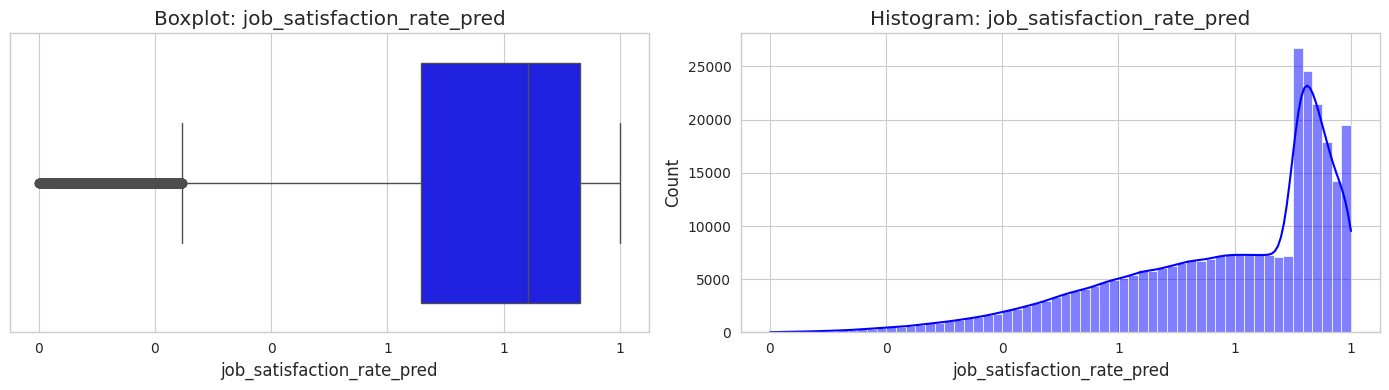

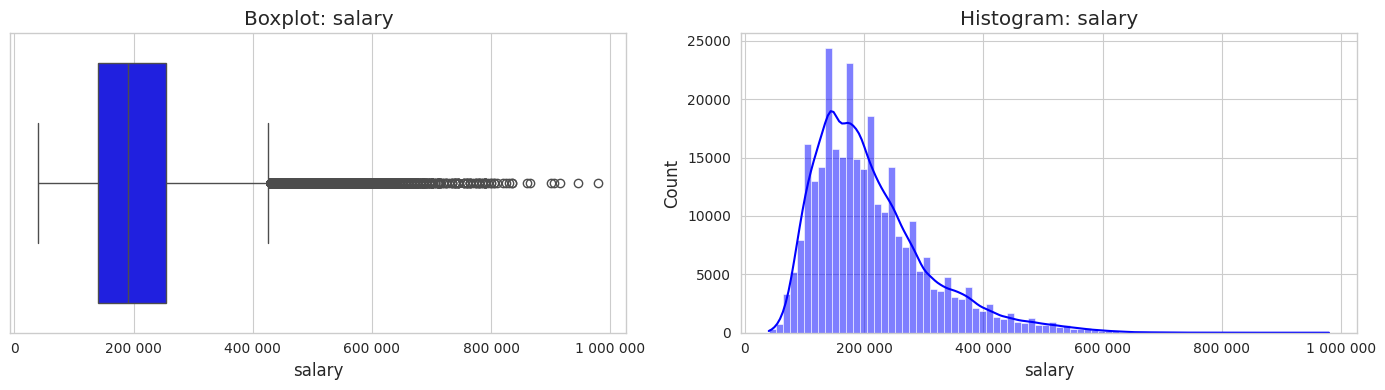

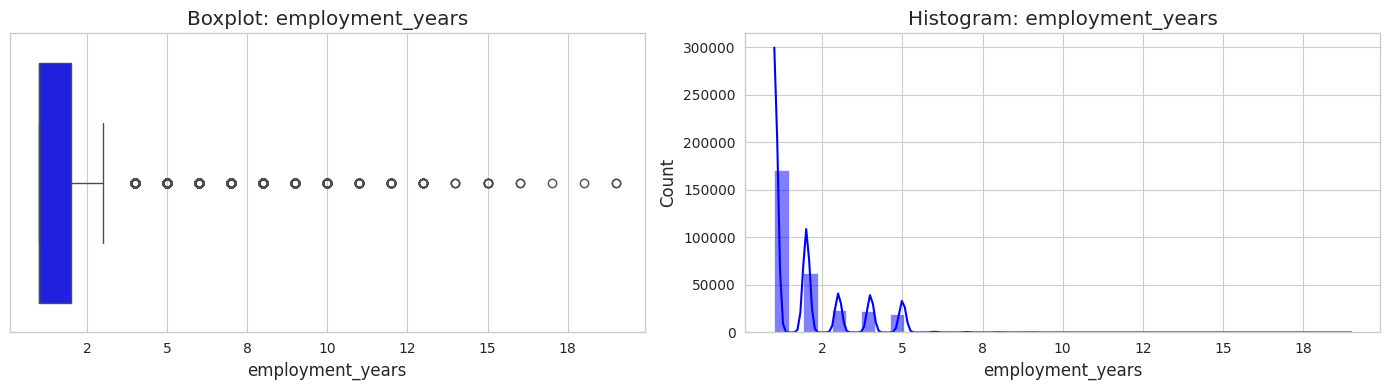

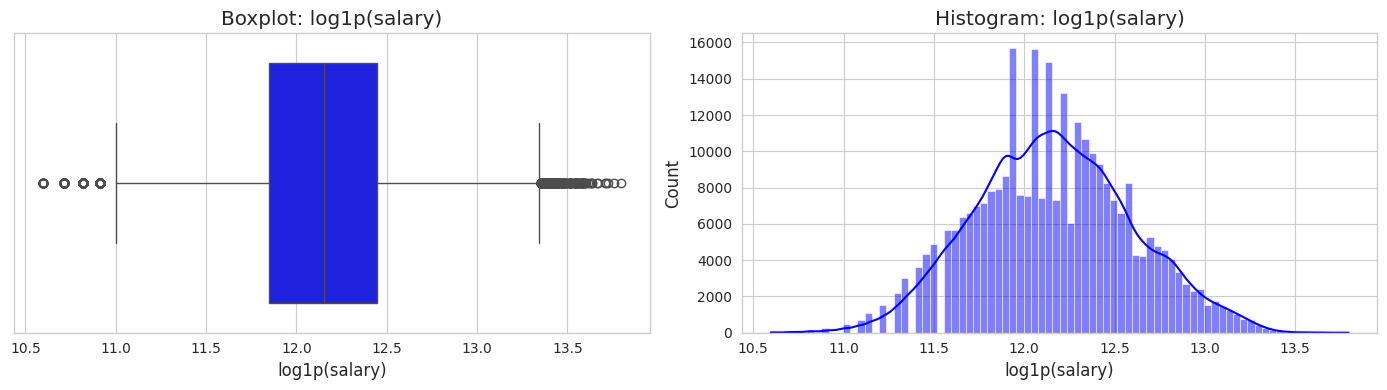

In [ ]:
# Визуализация количественных признаков
import matplotlib.ticker as mticker

sns.set_style("whitegrid")

df_plot = df

num_cols = ["job_satisfaction_rate_pred", "salary", "employment_years"]
SAMPLE_N = 300_000
bins_map = {"job_satisfaction_rate_pred": 60, "salary": 80, "employment_years": 40}

def fmt_space_thousands(x, pos=None):
    if np.isnan(x):
        return ""
    return f"{x:,.0f}".replace(",", " ")

def plot_box_hist(col):
    x = pd.to_numeric(df_plot[col], errors="coerce").dropna()
    if len(x) > SAMPLE_N:
        x = x.sample(SAMPLE_N, random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.boxplot(x=x, ax=axes[0], color="blue")
    axes[0].set_title(f"Boxplot: {col}")
    axes[0].set_xlabel(col)

    sns.histplot(x, bins=bins_map.get(col, 60), kde=True, ax=axes[1], color="blue")
    axes[1].set_title(f"Histogram: {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Count")

    # Отключаем scientific notation
    for ax in axes:
        ax.ticklabel_format(style="plain", axis="x", useOffset=False)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_space_thousands))

    plt.tight_layout()
    plt.show()

# Контроль диапазонов
print(df_plot[num_cols].agg(["min", "max"]).T)

# Графики для числовых признаков
for c in num_cols:
    plot_box_hist(c)

# Дополнительно: log1p(salary) (полезно для длинного хвоста)
sal = pd.to_numeric(df_plot["salary"], errors="coerce")
sal = sal[sal > 0].dropna()
if len(sal) > SAMPLE_N:
    sal = sal.sample(SAMPLE_N, random_state=42)

log_sal = np.log1p(sal)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=log_sal, ax=axes[0], color="blue")
axes[0].set_title("Boxplot: log1p(salary)")
axes[0].set_xlabel("log1p(salary)")

sns.histplot(log_sal, bins=80, kde=True, ax=axes[1], color="blue")
axes[1].set_title("Histogram: log1p(salary)")
axes[1].set_xlabel("log1p(salary)")
axes[1].set_ylabel("Count")

# для лог-зарплаты тоже уберём scientific notation
for ax in axes:
    ax.ticklabel_format(style="plain", axis="x", useOffset=False)

plt.tight_layout()
plt.show()


Boxplot выделяет значения за пределами 1.5*IQR как выбросы, однако для скошенных распределений (например, зарплаты) это отражает естественный длинный хвост, а не ошибки. Так как значения находятся в реалистичных пределах, выбросы не удалялись; для снижения влияния длинного хвоста при моделировании может использоваться лог-преобразование зарплаты (log1p).

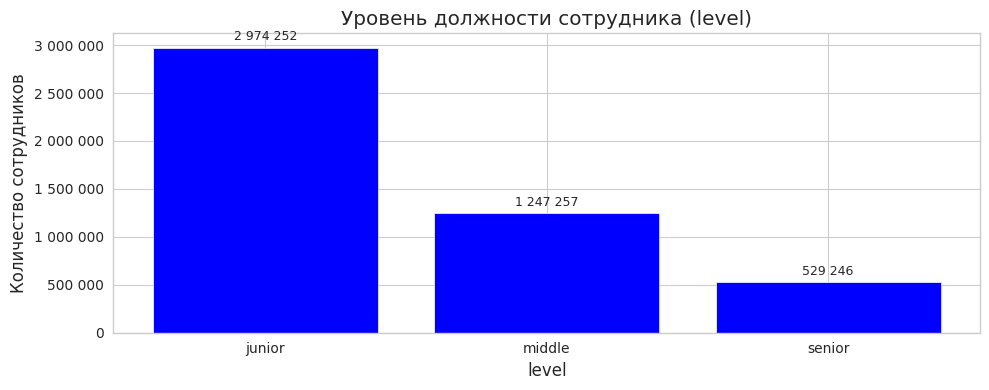

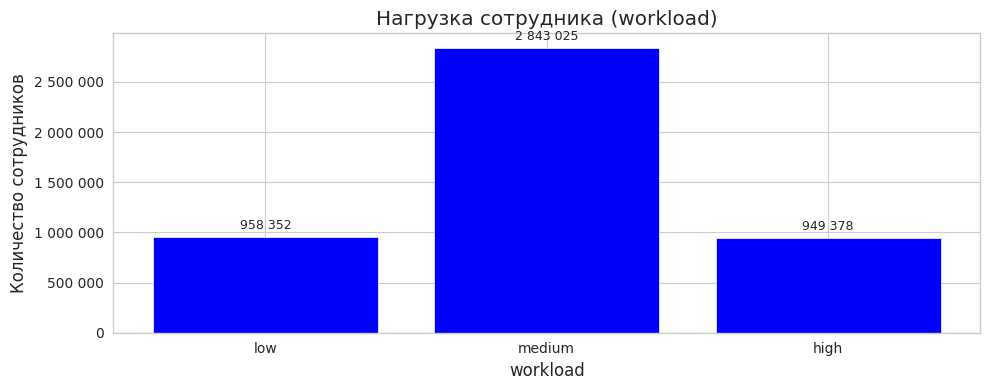

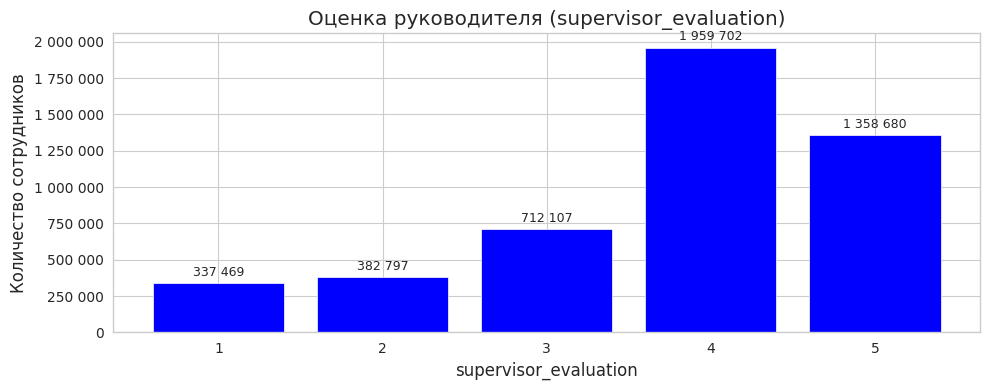

In [ ]:
# Визуализация ординальных (качественных с порядком) признаков

def fmt_space_thousands(x, pos=None):
    return f"{x:,.0f}".replace(",", " ")

ord_specs = [
    ("level", ["junior", "middle", "senior"], "Уровень должности сотрудника (level)"),
    ("workload", ["low", "medium", "high"], "Нагрузка сотрудника (workload)"),
    ("supervisor_evaluation", [1, 2, 3, 4, 5], "Оценка руководителя (supervisor_evaluation)"),
]

for col, order, title in ord_specs:
    s = df[col]

    # supervisor_evaluation на всякий случай приводим к числу, чтобы порядок 1..5 работал корректно
    if col == "supervisor_evaluation":
        s = pd.to_numeric(s, errors="coerce")

    vc = s.value_counts(dropna=False)

    # выстраиваем в нужном порядке
    idx = list(order)
    rest = [i for i in vc.index.tolist() if i not in idx]
    vc = vc.reindex(idx + rest)

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar([str(i) for i in vc.index], vc.values, color="blue")

    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Количество сотрудников")

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_space_thousands))
    plt.xticks(rotation=0)

    # подписи над столбиками
    for b in bars:
        h = b.get_height()
        ax.annotate(
            f"{int(h):,}".replace(",", " "),
            (b.get_x() + b.get_width() / 2, h),
            ha="center", va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

    plt.tight_layout()
    plt.show()


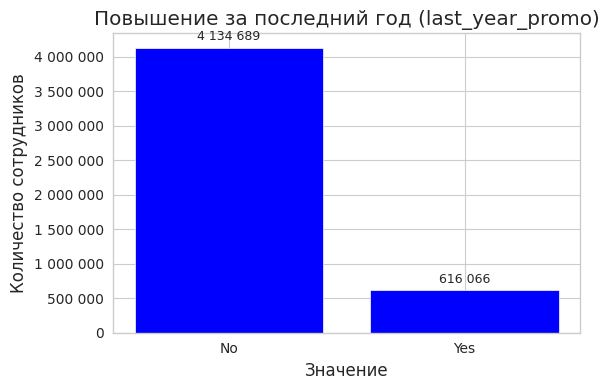

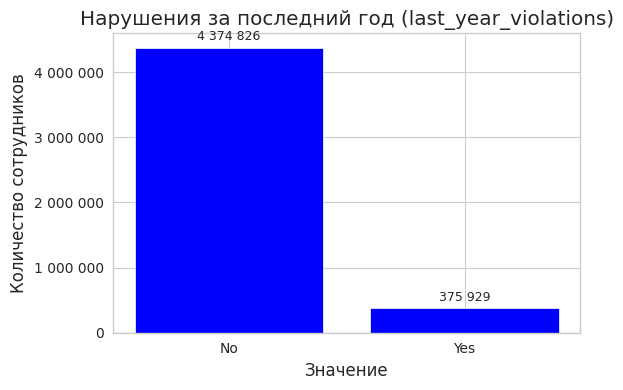

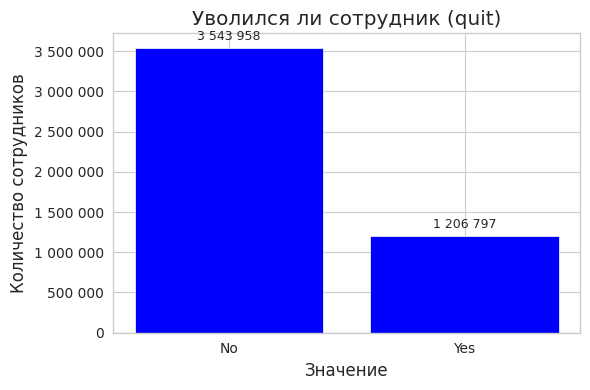

In [ ]:
# Визуализация бинарных признаков

def fmt_space_thousands(x, pos=None):
    return f"{x:,.0f}".replace(",", " ")

bin_specs = [
    ("last_year_promo", "Повышение за последний год (last_year_promo)"),
    ("last_year_violations", "Нарушения за последний год (last_year_violations)"),
    ("quit", "Уволился ли сотрудник (quit)"),
]

x_labels = ["No", "Yes"]  # 0 -> No, 1 -> Yes

for col, title in bin_specs:
    # гарантируем порядок [0, 1]
    vc = df[col].value_counts(dropna=False).reindex([0, 1], fill_value=0)

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(x_labels, vc.values, color="blue")

    ax.set_title(title)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Количество сотрудников")

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_space_thousands))

    # подписи над столбиками
    for b in bars:
        h = b.get_height()
        ax.annotate(
            f"{int(h):,}".replace(",", " "),
            (b.get_x() + b.get_width() / 2, h),
            ha="center", va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

    plt.tight_layout()
    plt.show()


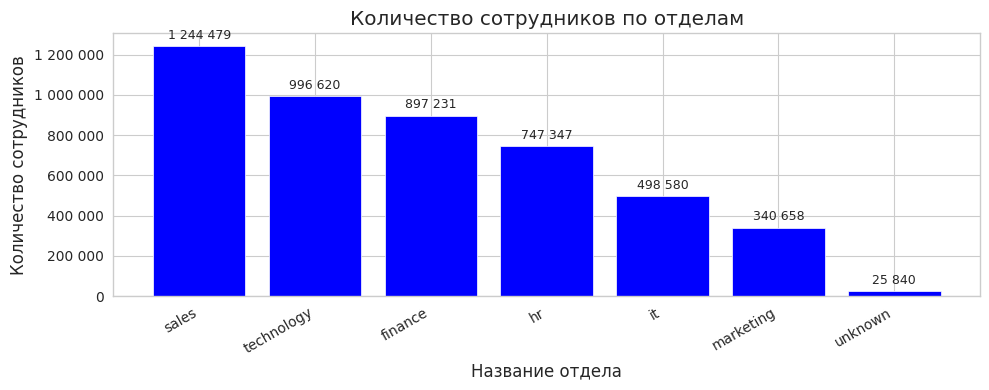

In [ ]:
# Визуализация номинального (качественного без порядка) признака - dept
import matplotlib.ticker as mticker

def fmt_space_thousands(x, pos=None):
    return f"{x:,.0f}".replace(",", " ")

col = "dept"
vc = df[col].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(vc.index.astype(str), vc.values, color="blue")

ax.set_title("Количество сотрудников по отделам")
ax.set_xlabel("Название отдела")
ax.set_ylabel("Количество сотрудников")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_space_thousands))
plt.xticks(rotation=30, ha="right")

# подписи над столбиками
for b in bars:
    h = b.get_height()
    ax.annotate(
        f"{int(h):,}".replace(",", " "),
        (b.get_x() + b.get_width() / 2, h),
        ha="center", va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()


Построим круговые диаграммы для визуализации долей составных частей в целом показателе в номинальном признаке dept и бинарном quit.

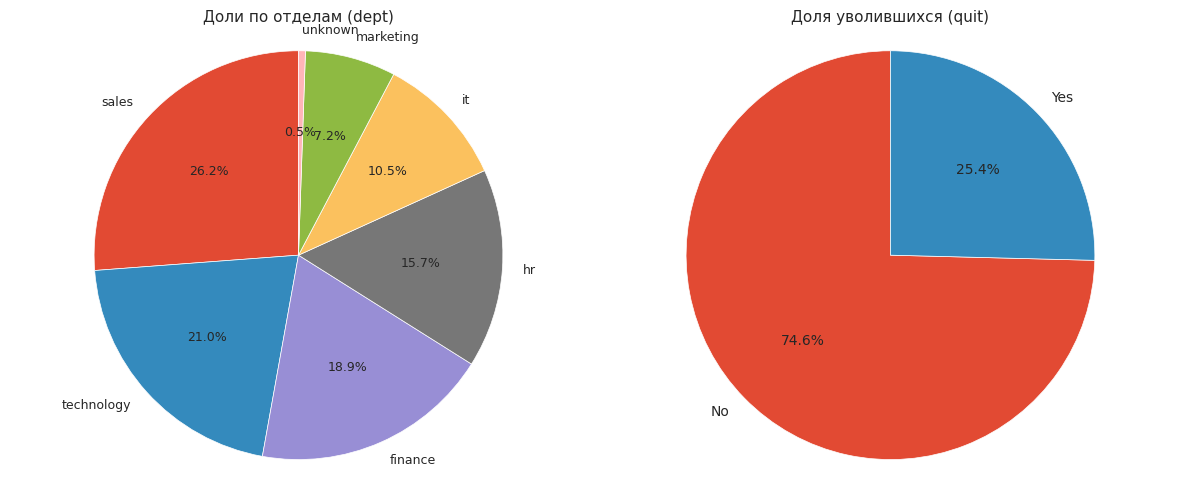

In [ ]:
# Круговые диаграммы

dept_counts = df["dept"].value_counts(dropna=False)
quit_counts = df["quit"].value_counts(dropna=False).reindex([0, 1], fill_value=0)
quit_labels = ["No", "Yes"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# dept
axes[0].pie(
    dept_counts.values,
    labels=dept_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 9}
)
axes[0].set_title("Доли по отделам (dept)", fontsize=11)
axes[0].axis("equal")

# quit
axes[1].pie(
    quit_counts.values,
    labels=quit_labels,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 10}
)
axes[1].set_title("Доля уволившихся (quit)", fontsize=11)
axes[1].axis("equal")

plt.tight_layout()
plt.show()


# **Вариант B_Снова вычислим метрики, но теперь уже на всех данных, с удаленными или перешифрованными пропусками/ аномальными значениями**

1. Вычисление медианного трудового стажа (employment_years) для каждого уровня должности (junior, middle, senior).

In [ ]:
# Медианный трудовой стаж по уровню должности (уже на очищенных/заполненных данных)
level_order = ["junior", "middle", "senior"]

median_employment_by_level = (
    df.groupby("level")["employment_years"]
      .median()
      .reindex(level_order)
)

print(median_employment_by_level)

level
junior    1.0
middle    2.0
senior    5.0
Name: employment_years, dtype: float64


**Расчет по варианту B дает тот же результат, что и по варианту A.**

2. Вычисление средней заработной платы (salary) для каждого уровня должности (junior, middle, senior) - общую и по отделам.

In [ ]:
level_order = ["junior", "middle", "senior"]

# 1) Средняя зарплата по уровню (общая)
avg_salary_by_level = (
    df.groupby("level")["salary"]
      .mean()
      .reindex(level_order)
      .round(0)
      .astype("Int64")
)

print("Средняя зарплата по уровню (целые):")
print(avg_salary_by_level)

# 2) Средняя зарплата по уровню и отделу
avg_salary_by_level_dept = (
    df.groupby(["level", "dept"])["salary"]
      .mean()
      .unstack("dept")
      .reindex(level_order)
      .round(0)
      .astype("Int64")
)

print("\nСредняя зарплата по уровню и отделу (целые):")
display(avg_salary_by_level_dept)


Средняя зарплата по уровню (целые):
level
junior    163521
middle    252488
senior    381786
Name: salary, dtype: Int64

Средняя зарплата по уровню и отделу (целые):


dept,finance,hr,it,marketing,sales,technology,unknown
level,,,,,,,
junior,199456,139667,188715,108035,149131,179124,174369
middle,315934,203170,295221,135370,221240,277457,247247
senior,476479,291222,443106,270665,320666,413505,366733


**Средняя заработная плата (общая и по установленным отделам) до тысяч совпадает с расчетом по варианту A.**

3. Нахождение отдела с наибольшим процентом уволившихся.

In [ ]:
# quit уже 0/1 без пропусков
quit_pct_by_dept = df.groupby("dept")["quit"].mean() * 100

top_dept = quit_pct_by_dept.idxmax()
top_pct = quit_pct_by_dept.loc[top_dept]

print("Отдел с наибольшим процентом уволившихся:", top_dept)
print(f"Процент уволившихся: {top_pct:.2f}%")

display(quit_pct_by_dept.sort_values(ascending=False).round(2))


Отдел с наибольшим процентом уволившихся: hr
Процент уволившихся: 66.43%


,quit
dept,
hr,66.43
marketing,55.7
unknown,30.89
sales,20.98
it,19.49
technology,9.73
finance,6.38


**По известным названиям отделов процент уволившихся до целых значений процентов  совпадает с вариантом A.**

**9. Для дальнейшего моделирования перешифруем качественные (номинальные и ординальные) признаки.**

Для номинального dept применим one-hot-encoding, для ординальных level, workload - ordinal encoding.

In [ ]:
# One-Hot Encoding для dept
dept_ohe = pd.get_dummies(df["dept"], prefix="dept", dtype="Int64")

# добавляем новые колонки в датасет
df = pd.concat([df, dept_ohe], axis=1)

# (опционально) если исходный dept больше не нужен для модели - можно удалить
# df = df.drop(columns=["dept"])
print("Добавлено OHE-колонок:", dept_ohe.shape[1])


Добавлено OHE-колонок: 7


In [ ]:
# Ordinal encoding для level и workload (сохраняем порядок)
level_map = {"junior": 0, "middle": 1, "senior": 2}
workload_map = {"low": 0, "medium": 1, "high": 2}

df["level_ord"] = df["level"].map(level_map).astype("Int64")
df["workload_ord"] = df["workload"].map(workload_map).astype("Int64")

# проверяем, не осталось ли неожиданных значений
print("level_ord NaN:", df["level_ord"].isna().sum())
print("workload_ord NaN:", df["workload_ord"].isna().sum())


level_ord NaN: 0
workload_ord NaN: 0


Теперь выводим статистику по обновленному датасету: размер, типы данных, количество пропусков по столбцам, первые 5 строк.

In [ ]:
# 1) Размер датасета
print("Размер датасета (строки, столбцы):", df.shape)

# 2) Типы данных
print("\nТипы данных по столбцам:")
print(df.dtypes)

# 3) Количество пропусков по столбцам (+ доля, если нужно)
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(4)

missing_stats = (
    pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
      .sort_values("missing_count", ascending=False)
)

print("\nПропуски по столбцам:")
display(missing_stats[missing_stats["missing_count"] > 0])

# 4) Первые 5 строк
display(df.head())


Размер датасета (строки, столбцы): (4750755, 31)

Типы данных по столбцам:
id                                            int64
dept                                 string[python]
level                                        object
workload                                     object
employment_years                            float64
last_year_promo                               Int64
last_year_violations                          Int64
supervisor_evaluation                       float64
salary                                      float64
quit                                          Int64
job_satisfaction_rate_pred                  float64
salary_was_missing                            Int64
employment_years_was_missing                  Int64
employment_years_was_anomaly                  Int64
salary_was_anomaly                            Int64
dept_was_missing                              Int64
level_was_missing                             Int64
workload_was_missing                     

,missing_count,missing_pct


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,...,quit_was_missing,dept_finance,dept_hr,dept_it,dept_marketing,dept_sales,dept_technology,dept_unknown,level_ord,workload_ord
0,690679,finance,junior,medium,1.0,0,0,4.0,175000.0,1,...,0,1,0,0,0,0,0,0,0,1
1,125148,hr,senior,low,3.0,0,0,2.0,280000.0,0,...,0,0,1,0,0,0,0,0,2,0
2,311009,sales,junior,high,2.0,0,0,1.0,105000.0,0,...,0,0,0,0,0,1,0,0,0,2
3,908488,finance,junior,medium,1.0,0,0,2.0,100000.0,0,...,0,1,0,0,0,0,0,0,0,1
4,756857,technology,junior,medium,1.0,0,0,2.0,100000.0,1,...,0,0,0,0,0,0,1,0,0,1


**10. Проверка гипотез для моделирования, поиск инсайтов во взаимосвязи признаков и целевой переменной**

In [ ]:
# Таблицы
# работаем с df (очищенный) или df_ml
data = df
target = "job_satisfaction_rate_pred"

# -----------------------------
# Таблицы: таргет по группам
# -----------------------------
group_cols = ["level", "dept", "workload", "supervisor_evaluation", "quit"]

summary_tables = {}
for col in group_cols:
    if col not in data.columns:
        continue

    t = (data.groupby(col)[target]
             .agg(count="size", mean="mean", median="median")
             .sort_values("mean", ascending=False))

    summary_tables[col] = t
    print(f"\n=== Target by {col} ===")
    display(t.round(4))

# -----------------------------
# Доля "почти 1" (потолочный эффект): y > 0.95
# -----------------------------
thr = 0.95
for col in group_cols:
    if col not in data.columns:
        continue

    ceiling = (data.assign(is_high=(data[target] > thr).astype(int))
                  .groupby(col)["is_high"]
                  .mean()
                  .sort_values(ascending=False) * 100)

    print(f"\n=== Share of y > {thr} by {col} (%) ===")
    display(ceiling.round(2))




=== Target by level ===


,count,mean,median
level,,,
senior,529246,0.8959,0.9355
middle,1247257,0.8171,0.8929
junior,2974252,0.7439,0.7853



=== Target by dept ===


,count,mean,median
dept,,,
finance,897231,0.9149,0.9358
it,498580,0.8379,0.9022
technology,996620,0.8187,0.8767
hr,747347,0.8059,0.8563
unknown,25840,0.7716,0.8258
sales,1244479,0.6812,0.6975
marketing,340658,0.5327,0.5433



=== Target by workload ===


...

,is_high
workload,
medium,18.47
low,16.76
high,14.32



=== Share of y > 0.95 by supervisor_evaluation (%) ===


,is_high
supervisor_evaluation,
5.0,21.61
4.0,21.22
3.0,12.35
2.0,3.37
1.0,3.34



=== Share of y > 0.95 by quit (%) ===


,is_high
quit,
0,19.81
1,9.90


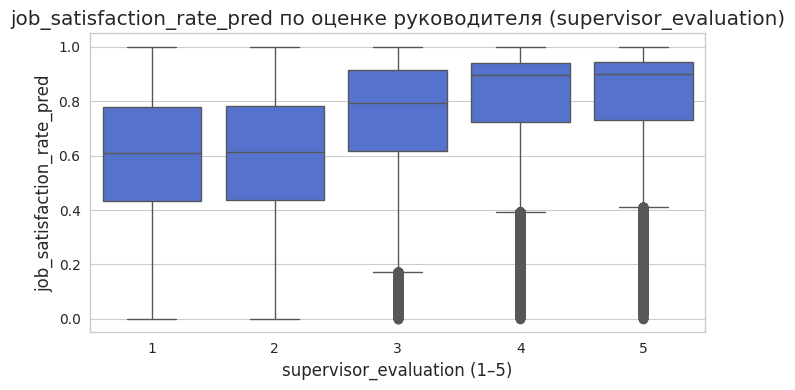

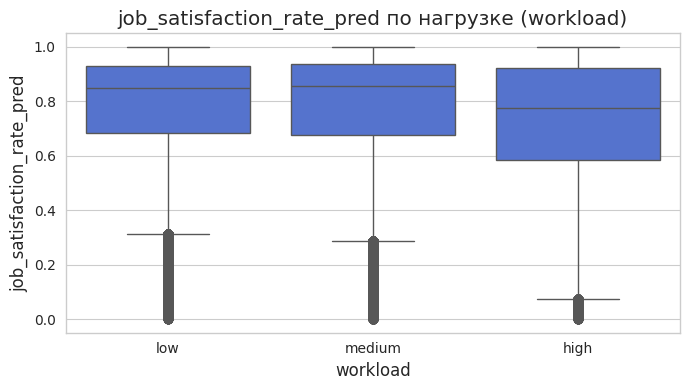

/tmp/ipython-input-2733121821.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_bin_stats = (tmp.groupby("salary_decile")[target]


,salary_decile,count,mean,median
0,"(39999.999, 110000.0]",530594,0.603761,0.603905
1,"(110000.0, 130000.0]",427539,0.685171,0.697310
2,"(130000.0, 150000.0]",516204,0.719927,0.743871
3,"(150000.0, 170000.0]",475437,0.769040,0.813172
4,"(170000.0, 190000.0]",479994,0.778895,0.824649
5,"(190000.0, 210000.0]",420915,0.795835,0.846991
6,"(210000.0, 240000.0]",509656,0.823182,0.891208
7,"(240000.0, 275000.0]",449959,0.850270,0.909531
8,"(275000.0, 345000.0]",476227,0.872958,0.920029
9,"(345000.0, 995000.0]",464230,0.923361,0.949523


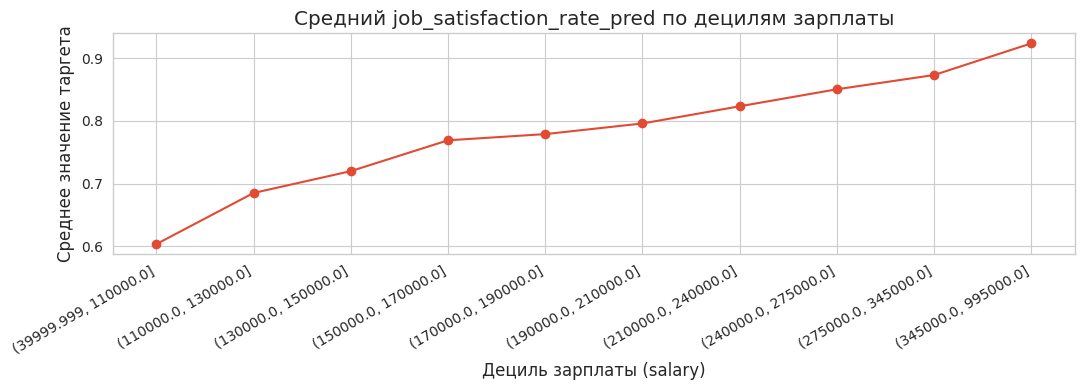

In [ ]:
# Графики

sns.set_style("whitegrid")

data = df  # или df_ml, если там есть нужные колонки
target = "job_satisfaction_rate_pred"

# ---------- 1) supervisor_evaluation -> y (исправление) ----------
# делаем целочисленную категорию 1..5
data = data.copy()
data["supervisor_evaluation_num"] = pd.to_numeric(data["supervisor_evaluation"], errors="coerce")

# если вдруг есть значения вне 1..5 — уберём их из графика
mask_sup = data["supervisor_evaluation_num"].between(1, 5)
plot_sup = data.loc[mask_sup, ["supervisor_evaluation_num", target]].copy()

plot_sup["supervisor_evaluation_cat"] = (
    plot_sup["supervisor_evaluation_num"]
    .round()
    .astype("Int64")
    .astype("string")
)

order_sup = ["1", "2", "3", "4", "5"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=plot_sup,
    x="supervisor_evaluation_cat",
    y=target,
    order=order_sup,
    ax=ax,
    color="royalblue"
)
ax.set_title("job_satisfaction_rate_pred по оценке руководителя (supervisor_evaluation)")
ax.set_xlabel("supervisor_evaluation (1–5)")
ax.set_ylabel(target)
plt.tight_layout()
plt.show()


# ---------- 2) workload -> y ----------
order_workload = ["low", "medium", "high"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=data,
    x="workload",
    y=target,
    order=order_workload,
    ax=ax,
    color="royalblue"
)
ax.set_title("job_satisfaction_rate_pred по нагрузке (workload)")
ax.set_xlabel("workload")
ax.set_ylabel(target)
plt.tight_layout()
plt.show()


# ---------- 3) salary bins (децили) -> mean y ----------
tmp = data[[target, "salary"]].copy()
tmp["salary"] = pd.to_numeric(tmp["salary"], errors="coerce")

tmp = tmp.dropna(subset=["salary", target]).copy()
tmp["salary_decile"] = pd.qcut(tmp["salary"], q=10, duplicates="drop")

salary_bin_stats = (tmp.groupby("salary_decile")[target]
                      .agg(count="size", mean="mean", median="median")
                      .reset_index())

display(salary_bin_stats)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(salary_bin_stats["salary_decile"].astype(str), salary_bin_stats["mean"], marker="o")
ax.set_title("Средний job_satisfaction_rate_pred по децилям зарплаты")
ax.set_xlabel("Дециль зарплаты (salary)")
ax.set_ylabel("Среднее значение таргета")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


В рамках разведочного анализа построены сводные таблицы зависимости целевой переменной job_satisfaction_rate_pred от ключевых признаков: level, dept, workload, supervisor_evaluation, quit, а также рассчитана доля «почти максимальных» значений таргета (y > 0.95) в каждой группе. Результаты показывают устойчивые и интерпретируемые различия между группами, что подтверждает информативность признаков для будущего моделирования.

По уровню должности (level) наблюдается выраженный градиент удовлетворённости: у junior среднее значение таргета составляет ~0.744, у middle ~0.817, у senior ~0.896. Аналогично растёт «потолочный эффект» (доля y > 0.95): примерно 11.4% у junior, 21.1% у middle и 41.5% у senior. Это указывает на систематическую связь уровня позиции с предсказанной удовлетворённостью и подтверждает, что уровень является сильным фактором.

По отделам (dept) различия также значимы. Наиболее высокий средний уровень удовлетворённости наблюдается у сотрудников finance (~0.915), далее it (~0.838) и technology (~0.819). Ниже находятся sales (~0.681), а минимальные значения в среднем у marketing (~0.533). Доля «очень высокой удовлетворённости» (y > 0.95) по отделам сильно варьируется: от 37.5% в finance до менее 1% в marketing. Это подтверждает, что принадлежность к отделу несёт существенную информацию и должна учитываться в модели (например, через one-hot encoding).

Для нагрузки (workload) различия более умеренные, но устойчивые: при high средняя удовлетворённость ниже (~0.734), чем при low и medium (~0.792). Это может отражать эффект перегрузки: более высокая нагрузка ассоциируется с более низкими значениями целевой переменной.

Наиболее сильная зависимость обнаружена по оценке руководителя (supervisor_evaluation). В сводной таблице средние значения таргета резко различаются между оценками 1-2 и 3-5: при 1-2 mean около 0.60, при 3 ~0.754, при 4-5 уже ~0.823–0.827. Доля y > 0.95 также существенно выше при 4-5 (≈21%) и крайне низкая при 1-2 (≈3%). Боксплот дополнительно подтверждает эту картину: распределения для 4-5 сдвинуты вверх (более высокие медианы и верхние квартили), а для 1-2 - заметно ниже. Следовательно, supervisor_evaluation является одним из самых информативных признаков и потенциально сильным предиктором.

Признак увольнения (quit) также демонстрирует ожидаемую связь с удовлетворённостью: у сотрудников, которые не уволились (quit=0), средняя удовлетворённость выше (~0.802), чем у уволившихся (quit=1, ~0.716). Доля «очень высокой удовлетворённости» (y > 0.95) в группе quit=0 составляет около 19.8%, а в группе quit=1 - около 9.9%. Это согласуется с бизнес-логикой: увольнение чаще связано с более низкой удовлетворённостью.

Дополнительно проведён анализ зависимости удовлетворённости от зарплаты через разбиение salary на децили. Получена чёткая монотонная тенденция: при росте зарплаты средняя удовлетворённость возрастает от ~0.604 в нижнем дециле (до ~110 тыс.) до ~0.923 в верхнем дециле (≈345 тыс. - 995 тыс.). Линейный график средних по децилям показывает устойчивый рост без резких инверсий, что указывает на сильную и стабильную положительную связь между уровнем дохода и целевой переменной. Такой вид зависимости может быть нелинейным в исходной шкале, поэтому для некоторых моделей может быть полезно рассмотреть преобразование зарплаты (например, log1p), однако даже без него признак явно информативен.

В целом таблицы и графики согласованно подтверждают: salary и supervisor_evaluation — наиболее сильные факторы; level и dept дают крупные и устойчивые различия; quit связан с таргетом ожидаемым образом; workload влияет умеренно, но стабильно. Эти результаты обосновывают использование указанных признаков в моделировании, а также необходимость корректного учёта категориальных признаков (one-hot для dept, ordinal encoding для level/workload) и предотвращения утечки данных при разбиении train/test по группам id.

**11. Готовим датасет для моделирования**

Убираем текстовые колонки с качественными признаками (мы их перешифровали через OHE и OE), id пока не убираем. так как, возможно, будем по нему группировать train и test

In [ ]:
target = "job_satisfaction_rate_pred"

# df_ml содержит id, но мы НЕ подаём id в модель
drop_text_cols = ["dept", "level", "workload"]   # только текстовые
df_ml = df.drop(columns=[c for c in drop_text_cols if c in df.columns]).copy()

# контроль: остались ли нечисловые
non_numeric = df_ml.select_dtypes(exclude=["number", "bool"]).columns
print("Нечисловые в df_ml:", non_numeric.tolist())


Нечисловые в df_ml: []


Теперь выводим статистику по датасету для моделирования: размер, типы данных, количество пропусков по столбцам, первые 5 строк.

In [ ]:
# 1) Размер датасета
print("Размер датасета (строки, столбцы):", df_ml.shape)

# 2) Типы данных
print("\nТипы данных по столбцам:")
print(df_ml.dtypes)

# 3) Количество пропусков по столбцам (+ доля, если нужно)
missing_count = df_ml.isna().sum()
missing_pct = (missing_count / len(df_ml) * 100).round(4)

missing_stats = (
    pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
      .sort_values("missing_count", ascending=False)
)

print("\nПропуски по столбцам:")
display(missing_stats[missing_stats["missing_count"] > 0])

# 4) Первые 5 строк
display(df_ml.head())


Размер датасета (строки, столбцы): (4750755, 28)

Типы данных по столбцам:
id                                     int64
employment_years                     float64
last_year_promo                        Int64
last_year_violations                   Int64
supervisor_evaluation                float64
salary                               float64
quit                                   Int64
job_satisfaction_rate_pred           float64
salary_was_missing                     Int64
employment_years_was_missing           Int64
employment_years_was_anomaly           Int64
salary_was_anomaly                     Int64
dept_was_missing                       Int64
level_was_missing                      Int64
workload_was_missing                   Int64
supervisor_evaluation_was_missing      Int64
last_year_promo_was_missing            Int64
last_year_violations_was_missing       Int64
quit_was_missing                       Int64
dept_finance                           Int64
dept_hr                  

,missing_count,missing_pct


,id,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate_pred,salary_was_missing,employment_years_was_missing,...,quit_was_missing,dept_finance,dept_hr,dept_it,dept_marketing,dept_sales,dept_technology,dept_unknown,level_ord,workload_ord
0,690679,1.0,0,0,4.0,175000.0,1,0.952281,0,0,...,0,1,0,0,0,0,0,0,0,1
1,125148,3.0,0,0,2.0,280000.0,0,0.745757,0,0,...,0,0,1,0,0,0,0,0,2,0
2,311009,2.0,0,0,1.0,105000.0,0,0.581074,0,0,...,0,0,0,0,0,1,0,0,0,2
3,908488,1.0,0,0,2.0,100000.0,0,0.671288,0,0,...,0,1,0,0,0,0,0,0,0,1
4,756857,1.0,0,0,2.0,100000.0,1,0.347873,0,0,...,0,0,0,0,0,0,1,0,0,1


In [ ]:
# Сохраняем обновленный датасет в файл
df_ml.to_csv("df_ml.csv", index=False)
print("Сохранено: df_ml.csv", df_ml.shape)

Сохранено: df_ml.csv (4750755, 28)


In [ ]:
# Скачиваем файл
from google.colab import files
files.download("df_ml.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**12. Разбиение выборки на train и test c учетом id сотрудника (один и тот же id не должен попадать в обучающую и тестовые выборки)**

In [ ]:
import numpy as np
import pandas as pd

target = "job_satisfaction_rate_pred"

# 1) Добавляем log_salary прямо в df_ml
df_ml["log_salary"] = np.log1p(df_ml["salary"])

# 2) X/y/groups
X_tree = df_ml.drop(columns=[target, "id"]).copy()   # id не подаём в модель
y = df_ml[target].copy()
groups = df_ml["id"].copy()



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# Числовые признаки, которые хотим масштабировать
num_cols = ["salary", "log_salary", "employment_years", "supervisor_evaluation"]

# (опционально) проверка, что все эти колонки есть
missing = [c for c in num_cols if c not in df_ml.columns]
print("Нет колонок (если пусто — ок):", missing)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), [c for c in num_cols if c in df_ml.columns]),
    ],
    remainder="passthrough"
)

pipe = Pipeline([
    ("prep", preprocess),
    ("model", Ridge())
])

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

X = df_ml.drop(columns=[target, "id"])
y = df_ml[target]
groups = df_ml["id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train rows:", X_train.shape, "Test rows:", X_test.shape)
print("Unique id train:", df_ml.loc[train_idx, "id"].nunique(),
      "Unique id test:", df_ml.loc[test_idx, "id"].nunique())
print("Пересечение id (должно быть 0):",
      len(set(df_ml.loc[train_idx, "id"]) & set(df_ml.loc[test_idx, "id"])))


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

def make_group_split(
    df_ml,
    target="job_satisfaction_rate_pred",
    group_col="id",
    test_size=0.2,
    random_state=42,
    drop_cols_in_X=None
):
    """
    Делает разбиение train/test так, чтобы один и тот же id не попадал в обе выборки.
    df_ml должен содержать столбцы target и group_col.

    drop_cols_in_X — список колонок, которые не должны попадать в признаки (например, ["id", target]).
    """

    if drop_cols_in_X is None:
        drop_cols_in_X = [target, group_col]
    else:
        drop_cols_in_X = list(set(drop_cols_in_X + [target, group_col]))

    X = df_ml.drop(columns=[c for c in drop_cols_in_X if c in df_ml.columns])
    y = df_ml[target]
    groups = df_ml[group_col]

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

    # проверки
    train_ids = set(df_ml.iloc[train_idx][group_col].tolist())
    test_ids = set(df_ml.iloc[test_idx][group_col].tolist())
    overlap = train_ids & test_ids

    print("Train rows:", X_train.shape, "| Test rows:", X_test.shape)
    print("Unique ids train:", len(train_ids), "| Unique ids test:", len(test_ids))
    print("ID overlap (должно быть 0):", len(overlap))

    return X_train, X_test, y_train, y_test, train_idx, test_idx

# пример использования:
# df_ml должен содержать id + target + числовые признаки
X_train, X_test, y_train, y_test, train_idx, test_idx = make_group_split(df_ml)

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
